# Sentinel-2 4 km Spatial-Aggregate SIF Model

Train a three-downsampling U-Net using 4 km x 4 km predictor chips at 20 m resolution. Each sample has one aggregate SIF target and one equal-footprint supervision weight map. The model predicts a 20 m SIF map; its weighted mean over the sampled footprint support is compared with the spatially aggregated OCO-2 SIF target.

## 1. Imports

In [6]:
from pathlib import Path
from collections import OrderedDict
import hashlib
import json
import math
import random

import altair as alt
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd
from shapely.geometry import box
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Sampler

alt.data_transformers.disable_max_rows()
pd.set_option('display.max_columns', 100)

## 2. Configuration

In [7]:
# Edit CHIP_DIR after attaching the Kaggle dataset.
CHIP_DIR = Path(
    '/kaggle/input/datasets/vishalt11/spatial-aggregate-4km-inout-evi-v1/spatial_aggregate_4km_20m_indices_updated_inout_evi_masked'
)
METADATA_PATH = CHIP_DIR / 'chip_metadata.csv'
FOOTPRINT_METADATA_PATH = CHIP_DIR / 'footprint_metadata.csv'

# Change this if the GPKG is mounted in a separate Kaggle dataset.
GERMANY_BOUNDARIES_PATH = Path('/kaggle/input/datasets/vishalt11/german-boundary/germany_boundaries.gpkg')
CHIP_BOUNDS_CRS = 'EPSG:32632'

OUTPUT_DIR = Path('/kaggle/working/sentinel2_spatial_aggregate_4km_model')
STATS_CACHE_DIR = Path('/kaggle/working/normalization_stats')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
STATS_CACHE_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = 'aggregated_target_modis_sif'

SEED = 42
TRAIN_FRAC = 0.80
VAL_FRAC = 0.10
TEST_FRAC = 0.10

BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 4
BASE_CHANNELS = 16
EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
HUBER_BETA = 1.0

EARLY_STOPPING_PATIENCE = 7
LR_PATIENCE = 3
LR_FACTOR = 0.5
MIN_LEARNING_RATE = 1e-6

NUM_WORKERS = 2
SHARD_CACHE_SIZE = 8
MAX_SAMPLES_FOR_STATS = 256
USE_STATS_CACHE = False
NORMALIZE_TARGET = True
USE_AMP = True

MIN_FOOTPRINTS = 5
SIF_BIN_EDGES = [-0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.25]
SIF_BIN_LABELS = [
    '[-0.5,-0.25)', '[-0.25,0)', '[0,0.25)', '[0.25,0.5)',
    '[0.5,0.75)', '[0.75,1)', '[1,1.25]'
]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_ENABLED = bool(USE_AMP and DEVICE.type == 'cuda')

print('device:', DEVICE)
print('AMP enabled:', AMP_ENABLED)
print('effective batch size:', BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)

device: cuda
AMP enabled: True
effective batch size: 32


## 3. Index Shards and Load Metadata

In [8]:
def decode_strings(values: np.ndarray) -> list[str]:
    output = []
    for value in values:
        if isinstance(value, bytes):
            output.append(value.decode('utf-8'))
        else:
            output.append(str(value))
    return output


def build_shard_index(chip_dir: Path) -> tuple[pd.DataFrame, list[str], list[str]]:
    shard_files = sorted(chip_dir.glob('chips_*.npz'))
    if not shard_files:
        raise FileNotFoundError(f'No chips_*.npz files found in {chip_dir}')

    rows = []
    channel_names = None
    target_names = None
    sample_order = 0

    for shard_id, shard_path in enumerate(shard_files):
        with np.load(shard_path, allow_pickle=False) as shard:
            aggregation_ids = decode_strings(shard['aggregation_id'])
            current_channels = decode_strings(shard['channel_names'])
            current_targets = decode_strings(shard['target_name'])

        if channel_names is None:
            channel_names = current_channels
            target_names = current_targets
        elif current_channels != channel_names or current_targets != target_names:
            raise ValueError(f'Inconsistent shard schema in {shard_path}')

        for local_index, aggregation_id in enumerate(aggregation_ids):
            rows.append({
                'sample_order': sample_order,
                'shard_id': shard_id,
                'shard_path': str(shard_path),
                'local_index': local_index,
                'aggregation_id': aggregation_id,
            })
            sample_order += 1

    shard_index = pd.DataFrame(rows)
    if shard_index['aggregation_id'].duplicated().any():
        raise ValueError(
            'Duplicate aggregation IDs found. Remove stale NPZ files and rebuild the dataset.'
        )
    return shard_index, channel_names, target_names


metadata = pd.read_csv(METADATA_PATH, parse_dates=['Delta_Date', 'par_date'])
footprint_metadata = pd.read_csv(FOOTPRINT_METADATA_PATH, parse_dates=['Delta_Date'])
shard_index, channel_names, target_names = build_shard_index(CHIP_DIR)

samples = metadata.merge(
    shard_index,
    on='aggregation_id',
    how='inner',
    validate='one_to_one',
)

if target_names != [TARGET_COL]:
    raise ValueError(f'Expected shard target {TARGET_COL}, found {target_names}')
if len(channel_names) != 19:
    raise ValueError(f'Expected 19 predictor channels, found {len(channel_names)}')

print('metadata rows:', len(metadata))
print('indexed shard rows:', len(shard_index))
print('merged samples:', len(samples))
print('channels:', len(channel_names), channel_names)
print('targets:', target_names)
samples.head()

metadata rows: 7920
indexed shard rows: 7920
merged samples: 7920
channels: 19 ['ndmi', 'ndvi', 'evi', 'nirv', 'ndre', 'fapar', 'par', 'apar', 'winter_wheat_fraction', 'winter_barley_fraction', 'winter_rye_fraction', 'maize_fraction', 'grass_forage_fraction', 'woody_fraction', 'other_crop_fraction', 'active_crop_fraction', 'non_crop_fraction', 'month_sin', 'month_cos']
targets: ['aggregated_target_modis_sif']


,aggregation_id,cell_id,Delta_Date,sif_year,sif_month,sif_doy,measurement_mode,date_align,quality_flag_values,n_quality_flag_0,n_quality_flag_1,quality_flag_1_fraction,mgrs_tile_t,product_path,fapar_composite_doy,par_date,n_footprints,y_aggregate,manifest_aggregated_target_modis_sif,target_sd,target_se,states,hzs_values,cell_xmin,cell_ymin,cell_xmax,cell_ymax,aggregate_weight_sum_float32,aggregate_support_pixels,aggregate_support_fraction,effective_weighted_pixels,mean_mask_inside_fraction,min_mask_inside_fraction,max_mask_inside_fraction,ndmi_valid_fraction,ndvi_valid_fraction,evi_valid_fraction,nirv_valid_fraction,ndre_valid_fraction,fapar_valid_fraction,par_valid_fraction,apar_valid_fraction,winter_wheat_fraction_valid_fraction,winter_barley_fraction_valid_fraction,winter_rye_fraction_valid_fraction,maize_fraction_valid_fraction,grass_forage_fraction_valid_fraction,woody_fraction_valid_fraction,other_crop_fraction_valid_fraction,active_crop_fraction_valid_fraction,non_crop_fraction_valid_fraction,month_sin_valid_fraction,month_cos_valid_fraction,shard_file,shard_index,sample_order,shard_id,shard_path,local_index
0,s2_fixed_4000m_T32UPU_r00_c24_20190206_m0,s2_fixed_4000m_T32UPU_r00_c24,2019-02-06,2019,2,37,0,outrange,0,8,0,0.000000,T32UPU,data\geodes_wasp_zips\32UPU\2019\SENTINEL2X_20...,33,2019-02-06,8,0.062253,0.062253,0.142744,0.050468,BAYERN,7b,696000.0,5396000.0,700000.0,5400000.0,1.0,26015,0.650375,23925.004981,0.800557,0.445410,0.999943,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,chips_00000.npz,0,0,0,/kaggle/input/datasets/vishalt11/spatial-aggre...,0
1,s2_fixed_4000m_T32UPU_r00_c25_20190206_m0,s2_fixed_4000m_T32UPU_r00_c25,2019-02-06,2019,2,37,0,outrange,0,7,0,0.000000,T32UPU,data\geodes_wasp_zips\32UPU\2019\SENTINEL2X_20...,33,2019-02-06,7,0.022292,0.022292,0.090907,0.034360,BAYERN,7b,700000.0,5396000.0,704000.0,5400000.0,1.0,22695,0.567375,21062.360442,0.830254,0.550180,1.000000,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,chips_00000.npz,1,1,0,/kaggle/input/datasets/vishalt11/spatial-aggre...,1
2,s2_fixed_4000m_T32UPU_r01_c24_20190206_m0,s2_fixed_4000m_T32UPU_r01_c24,2019-02-06,2019,2,37,0,outrange,0,5,0,0.000000,T32UPU,data\geodes_wasp_zips\32UPU\2019\SENTINEL2X_20...,33,2019-02-06,5,-0.000051,-0.000051,0.084210,0.037660,BAYERN,7b,696000.0,5392000.0,700000.0,5396000.0,1.0,15457,0.386425,13858.592939,0.760470,0.486793,1.000000,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,chips_00000.npz,2,2,0,/kaggle/input/datasets/vishalt11/spatial-aggre...,2
3,s2_fixed_4000m_T32UPU_r01_c25_20190206_m0,s2_fixed_4000m_T32UPU_r01_c25,2019-02-06,2019,2,37,0,outrange,0;1,8,1,0.111111,T32UPU,data\geodes_wasp_zips\32UPU\2019\SENTINEL2X_20...,33,2019-02-06,9,0.004843,0.004843,0.076959,0.025653,BAYERN,7b,700000.0,5392000.0,704000.0,5396000.0,1.0,30933,0.773325,29683.238757,0.864472,0.637926,1.000000,1.0,1.0,0.999975,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,chips_00000.npz,3,3,0,/kaggle/input/datasets/vishalt11/spatial-aggre...,3
4,s2_fixed_4000m_T32UPU_r02_c25_20190206_m0,s2_fixed_4000m_T32UPU_r02_c25,2019-02-06,2019,2,37,0,outrange,0;1,10,1,0.090909,T32UPU,data\geodes_wasp_zips\32UPU\2019\SENTINEL2X_20...,33,2019-02-06,11,-0.046556,-0.046556,0.067488,0.020348,BAYERN,7a;7b,700000.0,5388000.0,704000.0,5392000.0,1.0,34098,0.852450,30990.191521,0.769235,0.428006,0.999979,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,chips_00000.npz,4,4,0,/kaggle/input/datasets/vishalt11/spatial-aggre...,4


## 4. Filter and Inspect Aggregate Samples

In [9]:
samples['y_aggregate'] = pd.to_numeric(samples['y_aggregate'], errors='coerce')
samples['n_footprints'] = pd.to_numeric(samples['n_footprints'], errors='coerce')
samples['measurement_mode'] = pd.to_numeric(
    samples['measurement_mode'], errors='coerce'
)
samples['month'] = samples['Delta_Date'].dt.month.astype(int)

samples = samples[
    (samples['n_footprints'] >= MIN_FOOTPRINTS)
    & np.isfinite(samples['y_aggregate'])
    & samples['product_path'].notna()
].copy()

samples = samples.sort_values(
    ['sif_year', 'sif_doy', 'mgrs_tile_t', 'aggregation_id']
).reset_index(drop=True)

required_validity = [
    'ndmi_valid_fraction', 'ndvi_valid_fraction', 'evi_valid_fraction',
    'nirv_valid_fraction', 'ndre_valid_fraction', 'fapar_valid_fraction',
    'par_valid_fraction', 'apar_valid_fraction'
]
missing_validity = [column for column in required_validity if column not in samples.columns]
if missing_validity:
    raise ValueError(f'Missing predictor-validity columns: {missing_validity}')

print(f'Kept {len(samples):,} aggregate chips')
display(
    samples[
        ['n_footprints', *required_validity, 'y_aggregate']
    ].describe().T
)
display(
    samples.groupby(
        ['sif_year', 'month', 'measurement_mode'], dropna=False
    ).size().rename('n_chips').reset_index()
)

Kept 7,920 aggregate chips


,count,mean,std,min,25%,50%,75%,max
n_footprints,7920.0,8.921843,2.794575,5.000000,7.00000,9.000000,11.000000,18.000000
ndmi_valid_fraction,7920.0,0.968322,0.134428,0.000000,1.00000,1.000000,1.000000,1.000000
ndvi_valid_fraction,7920.0,0.968924,0.133209,0.000000,1.00000,1.000000,1.000000,1.000000
evi_valid_fraction,7920.0,0.968917,0.133158,0.000000,0.99995,1.000000,1.000000,1.000000
nirv_valid_fraction,7920.0,0.968924,0.133209,0.000000,1.00000,1.000000,1.000000,1.000000
ndre_valid_fraction,7920.0,0.968307,0.134441,0.000000,1.00000,1.000000,1.000000,1.000000
fapar_valid_fraction,7920.0,0.999963,0.001180,0.929550,1.00000,1.000000,1.000000,1.000000
par_valid_fraction,7920.0,0.996057,0.043286,0.251400,1.00000,1.000000,1.000000,1.000000
apar_valid_fraction,7920.0,0.996020,0.043299,0.251400,1.00000,1.000000,1.000000,1.000000
y_aggregate,7920.0,0.309895,0.166437,-0.093745,0.16958,0.314169,0.434967,0.878349


,sif_year,month,measurement_mode,n_chips
0,2019,2,0,42
1,2019,2,1,72
2,2019,3,0,55
3,2019,3,1,76
4,2019,4,0,175
...,...,...,...,...
62,2024,5,1,159
63,2024,6,0,38
64,2024,6,1,81
65,2024,7,0,121


## 5. Component-Preserving, Chip-Count-Balanced Train/Validation/Test Split

Rows connected by either the same Delta_Date or the same Sentinel product_path form one indivisible component. Complete components are assigned to approximately 80/10/10 of chips while balancing month, measurement mode, and MGRS tile. Year is not used for balancing.

In [10]:
def add_leakage_components(table: pd.DataFrame) -> pd.DataFrame:
    table = table.reset_index(drop=True).copy()
    n_rows = len(table)
    parent = np.arange(n_rows, dtype=np.int64)
    rank = np.zeros(n_rows, dtype=np.int8)

    def find(index: int) -> int:
        while parent[index] != index:
            parent[index] = parent[parent[index]]
            index = int(parent[index])
        return index

    def union(left: int, right: int) -> None:
        root_left = find(left)
        root_right = find(right)
        if root_left == root_right:
            return
        if rank[root_left] < rank[root_right]:
            root_left, root_right = root_right, root_left
        parent[root_right] = root_left
        if rank[root_left] == rank[root_right]:
            rank[root_left] += 1

    for column in ['Delta_Date', 'product_path']:
        for indices in table.groupby(column, dropna=False).indices.values():
            indices = np.asarray(indices, dtype=np.int64)
            first = int(indices[0])
            for index in indices[1:]:
                union(first, int(index))

    roots = np.asarray([find(index) for index in range(n_rows)])
    unique_roots = sorted(np.unique(roots).tolist())
    root_names = {
        root: f'component_{number:05d}'
        for number, root in enumerate(unique_roots)
    }
    table['split_component'] = [root_names[int(root)] for root in roots]
    return table


def component_summary_table(table: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for component, group in table.groupby('split_component', sort=False):
        months = sorted(group['month'].dropna().astype(int).unique().tolist())
        modes = sorted(
            group['measurement_mode'].dropna().astype(int).unique().tolist()
        )
        tiles = sorted(group['mgrs_tile_t'].dropna().astype(str).unique().tolist())
        rows.append({
            'split_component': component,
            'n_chips': len(group),
            'n_dates': group['Delta_Date'].nunique(),
            'n_products': group['product_path'].nunique(),
            'months': ';'.join(map(str, months)),
            'measurement_modes': ';'.join(map(str, modes)),
            'mgrs_tiles': ';'.join(tiles),
            'n_months': len(months),
            'n_modes': len(modes),
            'n_mgrs_tiles': len(tiles),
        })
    return pd.DataFrame(rows)


def build_component_balance_vectors(
    table: pd.DataFrame,
    components: pd.DataFrame,
    balance_columns: list[str],
) -> tuple[np.ndarray, list[str], np.ndarray, dict[str, list]]:
    component_ids = components['split_component'].tolist()
    grouped = {
        component: group
        for component, group in table.groupby('split_component', sort=False)
    }
    balance_levels = {
        column: sorted(
            table[column].dropna().unique().tolist(),
            key=lambda value: str(value),
        )
        for column in balance_columns
    }

    feature_labels = ['all_chips']
    feature_weights = [4.0]
    for column in balance_columns:
        levels = balance_levels[column]
        feature_labels.extend(
            [f'{column}={level}' for level in levels]
        )
        # Give month, mode, and tile equal total influence regardless of
        # how many levels each variable contains.
        feature_weights.extend([1.0 / len(levels)] * len(levels))

    vectors = np.zeros(
        (len(component_ids), len(feature_labels)),
        dtype=np.float64,
    )
    for component_index, component in enumerate(component_ids):
        group = grouped[component]
        vectors[component_index, 0] = len(group)
        feature_index = 1
        for column in balance_columns:
            counts = group[column].value_counts(dropna=False)
            for level in balance_levels[column]:
                vectors[component_index, feature_index] = float(
                    counts.get(level, 0)
                )
                feature_index += 1

    return (
        vectors,
        feature_labels,
        np.asarray(feature_weights, dtype=np.float64),
        balance_levels,
    )


def grouped_balanced_component_split(
    table: pd.DataFrame,
    n_restarts: int = 2000,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    table = add_leakage_components(table)
    components = component_summary_table(table)
    balance_columns = ['month', 'measurement_mode', 'mgrs_tile_t']
    (
        component_vectors,
        feature_labels,
        feature_weights,
        balance_levels,
    ) = build_component_balance_vectors(
        table,
        components,
        balance_columns,
    )

    # Every required level must occur in at least three separate components
    # before it can appear in all three splits.
    for column, levels in balance_levels.items():
        presence = (
            table[['split_component', column]]
            .drop_duplicates()
            .groupby(column, dropna=False)
            .size()
        )
        impossible = {
            str(level): int(presence.get(level, 0))
            for level in levels
            if int(presence.get(level, 0)) < 3
        }
        if impossible:
            raise ValueError(
                f'Cannot represent every {column} level in all splits. '
                f'Component counts: {impossible}'
            )

    split_names = np.asarray(['train', 'validation', 'test'])
    split_fractions = np.asarray(
        [TRAIN_FRAC, VAL_FRAC, TEST_FRAC],
        dtype=np.float64,
    )
    if np.any(split_fractions <= 0) or not np.isclose(
        split_fractions.sum(), 1.0
    ):
        raise ValueError(f'Invalid split fractions: {split_fractions}')

    feature_totals = component_vectors.sum(axis=0)
    target_counts = split_fractions[:, None] * feature_totals[None, :]
    target_scale = np.maximum(target_counts, 1.0)

    def balance_error(split_counts: np.ndarray) -> float:
        relative_error = (split_counts - target_counts) / target_scale
        return float(
            np.sum(
                feature_weights[None, :] * relative_error ** 2
            )
        )

    def final_objective(split_counts: np.ndarray) -> float:
        missing_required_levels = int(
            np.count_nonzero(split_counts[:, 1:] <= 0)
        )
        return (
            balance_error(split_counts)
            + 1_000_000.0 * missing_required_levels
        )

    rng = np.random.default_rng(SEED)
    best_assignments = None
    best_counts = None
    best_score = np.inf

    for _ in range(n_restarts):
        # Usually place large components first, with enough jitter for the
        # repeated searches to explore different valid allocations.
        priority = (
            component_vectors[:, 0]
            * rng.uniform(0.75, 1.25, size=len(components))
        )
        component_order = np.argsort(-priority)
        assignments = np.full(len(components), -1, dtype=np.int8)
        split_counts = np.zeros_like(target_counts)

        for component_index in component_order:
            candidate_scores = np.empty(len(split_names), dtype=np.float64)
            for split_index in range(len(split_names)):
                candidate_counts = split_counts.copy()
                candidate_counts[split_index] += component_vectors[
                    component_index
                ]
                candidate_scores[split_index] = balance_error(
                    candidate_counts
                )

            minimum = candidate_scores.min()
            best_candidates = np.flatnonzero(
                np.isclose(candidate_scores, minimum, rtol=1e-12, atol=1e-12)
            )
            chosen_split = int(rng.choice(best_candidates))
            assignments[component_index] = chosen_split
            split_counts[chosen_split] += component_vectors[component_index]

        score = final_objective(split_counts)
        if score < best_score:
            best_score = score
            best_assignments = assignments.copy()
            best_counts = split_counts.copy()

    if best_assignments is None or best_counts is None:
        raise RuntimeError('No component allocation was produced.')
    if np.any(best_counts[:, 1:] <= 0):
        raise RuntimeError(
            'Best allocation is missing at least one required month, mode, '
            'or MGRS tile.'
        )

    component_to_split = {
        component: split_names[int(split_index)]
        for component, split_index in zip(
            components['split_component'],
            best_assignments,
        )
    }
    table['split'] = table['split_component'].map(component_to_split)
    if table['split'].isna().any():
        raise RuntimeError('At least one leakage component was not assigned.')

    train = table[table['split'] == 'train'].copy().reset_index(drop=True)
    validation = (
        table[table['split'] == 'validation']
        .copy()
        .reset_index(drop=True)
    )
    test = table[table['split'] == 'test'].copy().reset_index(drop=True)
    if train.empty or validation.empty or test.empty:
        raise ValueError('Grouped split produced an empty split.')

    print('Best component-balance objective:', best_score)
    target_and_actual = pd.DataFrame({
        'split': split_names,
        'target_chips': target_counts[:, 0],
        'actual_chips': best_counts[:, 0].astype(int),
    })
    target_and_actual['actual_fraction'] = (
        target_and_actual['actual_chips'] / len(table)
    )
    display(target_and_actual)

    return train, validation, test, components


def assert_disjoint_values(
    left: pd.DataFrame,
    right: pd.DataFrame,
    column: str,
    label: str,
) -> None:
    shared = set(left[column].astype(str)) & set(right[column].astype(str))
    if shared:
        raise RuntimeError(f'{label} leakage detected: {len(shared)} shared values')


def assert_all_levels_present(
    full_table: pd.DataFrame,
    split_tables: dict[str, pd.DataFrame],
    column: str,
) -> None:
    expected = set(full_table[column].dropna().astype(str))
    for split_name, split_table in split_tables.items():
        observed = set(split_table[column].dropna().astype(str))
        missing = sorted(expected - observed)
        if missing:
            raise RuntimeError(
                f'{split_name} is missing {column} levels: {missing}'
            )


def marginal_split_summary(
    table: pd.DataFrame,
    column: str,
) -> pd.DataFrame:
    summary = (
        table.groupby(['split', column], dropna=False)
        .size()
        .rename('n_chips')
        .reset_index()
    )
    level_totals = (
        table.groupby(column, dropna=False)
        .size()
        .rename('level_total')
        .reset_index()
    )
    summary = summary.merge(level_totals, on=column, how='left')
    summary['fraction_of_level'] = (
        summary['n_chips'] / summary['level_total']
    )
    return summary.sort_values([column, 'split']).reset_index(drop=True)


train_table, val_table, test_table, split_components = (
    grouped_balanced_component_split(samples)
)

split_tables = {
    'train': train_table,
    'validation': val_table,
    'test': test_table,
}
for column in ['month', 'measurement_mode', 'mgrs_tile_t']:
    assert_all_levels_present(samples, split_tables, column)

for left_name, left, right_name, right in [
    ('train', train_table, 'validation', val_table),
    ('train', train_table, 'test', test_table),
    ('validation', val_table, 'test', test_table),
]:
    assert_disjoint_values(
        left, right, 'Delta_Date', f'{left_name}/{right_name} date'
    )
    assert_disjoint_values(
        left,
        right,
        'product_path',
        f'{left_name}/{right_name} Sentinel product',
    )

print(
    'train chips:', len(train_table),
    'dates:', train_table['Delta_Date'].nunique(),
    'products:', train_table['product_path'].nunique(),
)
print(
    'validation chips:', len(val_table),
    'dates:', val_table['Delta_Date'].nunique(),
    'products:', val_table['product_path'].nunique(),
)
print(
    'test chips:', len(test_table),
    'dates:', test_table['Delta_Date'].nunique(),
    'products:', test_table['product_path'].nunique(),
)

all_split_rows = pd.concat(
    [train_table, val_table, test_table],
    ignore_index=True,
)
for column in ['month', 'measurement_mode', 'mgrs_tile_t']:
    print(f'\nBalance by {column}:')
    display(marginal_split_summary(all_split_rows, column))

display(split_components.describe(include='all').T)

Best component-balance objective: 1.6378277980517788


,split,target_chips,actual_chips,actual_fraction
0,train,6336.0,6060,0.765152
1,validation,792.0,929,0.117298
2,test,792.0,931,0.117551


train chips: 6060 dates: 175 products: 188
validation chips: 929 dates: 24 products: 26
test chips: 931 dates: 21 products: 23

Balance by month:


,split,month,n_chips,level_total,fraction_of_level
0,test,2,45,470,0.095745
1,train,2,394,470,0.838298
2,validation,2,31,470,0.065957
3,test,3,99,1558,0.063543
4,train,3,1318,1558,0.845956
5,validation,3,141,1558,0.090501
6,test,4,376,1598,0.235294
7,train,4,947,1598,0.592616
8,validation,4,275,1598,0.172090
9,test,5,280,1536,0.182292



Balance by measurement_mode:


,split,measurement_mode,n_chips,level_total,fraction_of_level
0,test,0,486,3794,0.128097
1,train,0,2798,3794,0.737480
2,validation,0,510,3794,0.134423
3,test,1,445,4126,0.107853
4,train,1,3262,4126,0.790596
5,validation,1,419,4126,0.101551



Balance by mgrs_tile_t:


,split,mgrs_tile_t,n_chips,level_total,fraction_of_level
0,test,T32ULA,109,782,0.139386
1,train,T32ULA,604,782,0.772379
2,validation,T32ULA,69,782,0.088235
3,test,T32ULB,87,762,0.114173
4,train,T32ULB,602,762,0.790026
5,validation,T32ULB,73,762,0.095801
6,test,T32UMD,138,1194,0.115578
7,train,T32UMD,929,1194,0.778057
8,validation,T32UMD,127,1194,0.106365
9,test,T32UNA,150,949,0.158061


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
split_component,88,88,component_00000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_chips,88.0,NaN,NaN,NaN,90.0,96.58419,1.0,26.25,58.5,109.25,509.0
n_dates,88.0,NaN,NaN,NaN,2.5,1.531283,1.0,1.0,2.0,3.0,7.0
n_products,88.0,NaN,NaN,NaN,2.693182,1.877624,1.0,1.0,2.0,4.0,7.0
months,88,6,7,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
measurement_modes,88,3,0;1,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mgrs_tiles,88,25,T32ULA;T32ULB,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_months,88.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
n_modes,88.0,NaN,NaN,NaN,1.636364,0.483802,1.0,1.0,2.0,2.0,2.0
n_mgrs_tiles,88.0,NaN,NaN,NaN,2.693182,1.877624,1.0,1.0,2.0,4.0,7.0


In [11]:
component_split_lookup = pd.concat([
    train_table[['split_component']].assign(split='train'),
    val_table[['split_component']].assign(split='validation'),
    test_table[['split_component']].assign(split='test'),
]).drop_duplicates('split_component')
split_components = split_components.merge(
    component_split_lookup,
    on='split_component',
    how='left',
    validate='one_to_one',
)
if split_components['split'].isna().any():
    raise RuntimeError('A split component is missing its split label.')
display(split_components.groupby('split')['n_chips'].agg(['count', 'sum']))

,count,sum
split,,
test,8,931
train,73,6060
validation,7,929


## 6. Dataset, Shard Cache, and NaN-Aware Normalization

In [12]:
class NpzShardCache:
    def __init__(self, max_size: int):
        self.max_size = max(1, int(max_size))
        self.cache: OrderedDict[str, dict[str, np.ndarray]] = OrderedDict()

    def get(self, path: str) -> dict[str, np.ndarray]:
        if path in self.cache:
            self.cache.move_to_end(path)
            return self.cache[path]

        with np.load(path, allow_pickle=False) as shard:
            loaded = {
                'X': shard['X'].copy(),
                'aggregate_weight_map': shard['aggregate_weight_map'].copy(),
                'y_aggregate': shard['y_aggregate'].copy(),
                'n_footprints': shard['n_footprints'].copy(),
            }

        self.cache[path] = loaded
        self.cache.move_to_end(path)
        while len(self.cache) > self.max_size:
            self.cache.popitem(last=False)
        return loaded


class SentinelAggregateDataset(Dataset):
    def __init__(
        self,
        table: pd.DataFrame,
        channel_mean: np.ndarray | None = None,
        channel_std: np.ndarray | None = None,
        target_mean: float | None = None,
        target_std: float | None = None,
        cache_size: int = 8,
    ):
        self.table = table.reset_index(drop=True).copy()
        self.channel_mean = channel_mean
        self.channel_std = channel_std
        self.target_mean = target_mean
        self.target_std = target_std
        self.cache = NpzShardCache(cache_size)

    def __len__(self) -> int:
        return len(self.table)

    def __getitem__(self, index: int):
        row = self.table.iloc[index]
        shard = self.cache.get(str(row['shard_path']))
        local_index = int(row['local_index'])

        # Cast stored float16 arrays to float32 before normalization and training.
        x = shard['X'][local_index].astype(np.float32, copy=True)
        weight = shard['aggregate_weight_map'][local_index].astype(
            np.float32, copy=True
        )
        y = np.float32(shard['y_aggregate'][local_index])
        n_footprints = int(shard['n_footprints'][local_index])

        weight = np.nan_to_num(weight, nan=0.0, posinf=0.0, neginf=0.0)
        weight_sum = float(weight.sum(dtype=np.float64))
        if not np.isfinite(weight_sum) or weight_sum <= 0:
            raise ValueError(f'Invalid aggregate weight map at dataset index {index}')
        weight /= weight_sum

        if self.channel_mean is not None and self.channel_std is not None:
            x = (
                x - self.channel_mean[:, None, None]
            ) / self.channel_std[:, None, None]
            x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        if self.target_mean is not None and self.target_std is not None:
            y = np.float32((y - self.target_mean) / self.target_std)

        return (
            torch.from_numpy(x),
            torch.from_numpy(weight),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(n_footprints, dtype=torch.int16),
            torch.tensor(index, dtype=torch.long),
        )


def make_stats_cache_path(table: pd.DataFrame) -> Path:
    fields = [
        f'target={TARGET_COL}',
        f'seed={SEED}',
        f'max_stats={MAX_SAMPLES_FOR_STATS}',
        'channels=' + ','.join(channel_names),
        *sorted(table['aggregation_id'].astype(str).tolist()),
    ]
    digest = hashlib.md5('\n'.join(fields).encode('utf-8')).hexdigest()[:16]
    return STATS_CACHE_DIR / f'sentinel2_4km_normalization_{digest}.npz'


def compute_channel_stats(
    table: pd.DataFrame,
    max_samples: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(SEED)
    if len(table) > max_samples:
        selected = rng.choice(len(table), size=max_samples, replace=False)
        stat_table = table.iloc[selected].copy().reset_index(drop=True)
    else:
        stat_table = table.copy().reset_index(drop=True)

    dataset = SentinelAggregateDataset(stat_table, cache_size=SHARD_CACHE_SIZE)
    n_channels = len(channel_names)
    channel_sum = np.zeros(n_channels, dtype=np.float64)
    channel_sumsq = np.zeros(n_channels, dtype=np.float64)
    channel_count = np.zeros(n_channels, dtype=np.int64)

    for index in range(len(dataset)):
        x, _, _, _, _ = dataset[index]
        array = x.numpy()
        finite = np.isfinite(array)
        safe = np.where(finite, array, 0.0)
        channel_sum += safe.sum(axis=(1, 2), dtype=np.float64)
        channel_sumsq += (safe * safe).sum(axis=(1, 2), dtype=np.float64)
        channel_count += finite.sum(axis=(1, 2))

        if (index + 1) % 32 == 0 or index + 1 == len(dataset):
            print(f'Normalization stats: {index + 1} / {len(dataset)} chips')

    if (channel_count == 0).any():
        bad = np.asarray(channel_names)[channel_count == 0].tolist()
        raise ValueError(f'Channels have no valid training pixels: {bad}')

    mean = channel_sum / channel_count
    variance = np.maximum(channel_sumsq / channel_count - mean ** 2, 1e-8)
    std = np.sqrt(variance)
    return mean.astype(np.float32), std.astype(np.float32), channel_count


stats_cache_path = make_stats_cache_path(train_table)

if USE_STATS_CACHE and stats_cache_path.exists():
    print('Loading normalization stats:', stats_cache_path)
    with np.load(stats_cache_path, allow_pickle=False) as stats:
        cached_channels = decode_strings(stats['channel_names'])
        if cached_channels != channel_names:
            raise ValueError('Cached channel names do not match the dataset.')
        channel_mean = stats['channel_mean'].astype(np.float32)
        channel_std = stats['channel_std'].astype(np.float32)
        channel_count = stats['channel_count'].astype(np.int64)
        target_mean = float(stats['target_mean'])
        target_std = float(stats['target_std'])
else:
    print('Computing NaN-aware statistics from training chips...')
    channel_mean, channel_std, channel_count = compute_channel_stats(
        train_table,
        MAX_SAMPLES_FOR_STATS,
    )
    training_targets = train_table['y_aggregate'].to_numpy(dtype=np.float64)
    training_targets = training_targets[np.isfinite(training_targets)]
    target_mean = float(training_targets.mean())
    target_std = float(training_targets.std(ddof=1))
    if not np.isfinite(target_std) or target_std <= 0:
        raise ValueError(f'Invalid target standard deviation: {target_std}')

    np.savez_compressed(
        stats_cache_path,
        channel_names=np.asarray(channel_names),
        channel_mean=channel_mean,
        channel_std=channel_std,
        channel_count=channel_count,
        target_mean=np.asarray(target_mean, dtype=np.float32),
        target_std=np.asarray(target_std, dtype=np.float32),
    )
    print('Saved normalization stats:', stats_cache_path)

normalization_table = pd.DataFrame({
    'channel': channel_names,
    'mean': channel_mean,
    'std': channel_std,
    'valid_pixel_count': channel_count,
})
display(normalization_table)
print('target mean:', target_mean)
print('target std:', target_std)

Computing NaN-aware statistics from training chips...
Normalization stats: 32 / 256 chips
Normalization stats: 64 / 256 chips
Normalization stats: 96 / 256 chips
Normalization stats: 128 / 256 chips
Normalization stats: 160 / 256 chips
Normalization stats: 192 / 256 chips
Normalization stats: 224 / 256 chips
Normalization stats: 256 / 256 chips
Saved normalization stats: /kaggle/working/normalization_stats/sentinel2_4km_normalization_7e4ce253732116d6.npz


,channel,mean,std,valid_pixel_count
0,ndmi,0.184219,0.214143,9782352
1,ndvi,0.629521,0.236018,9787640
2,evi,0.413830,0.204123,9788771
3,nirv,0.200211,0.119911,9787640
4,ndre,0.465838,0.181201,9781903
5,fapar,0.611409,0.156627,10240000
6,par,101.196358,38.158642,10180630
7,apar,64.231171,33.118214,10180630
8,winter_wheat_fraction,0.077088,0.257740,10240000
9,winter_barley_fraction,0.038341,0.184667,10240000


target mean: 0.30902422607479124
target std: 0.17115807642224629


## 7. Shard-Aware DataLoaders

In [13]:
class ShardBatchSampler(Sampler[list[int]]):
    def __init__(
        self,
        table: pd.DataFrame,
        batch_size: int,
        shuffle: bool,
        seed: int,
    ):
        self.table = table.reset_index(drop=True)
        self.batch_size = int(batch_size)
        self.shuffle = bool(shuffle)
        self.seed = int(seed)
        self.epoch = 0
        self.groups = [
            np.asarray(indices, dtype=np.int64)
            for indices in self.table.groupby(
                'shard_path', sort=False
            ).indices.values()
        ]

    def set_epoch(self, epoch: int) -> None:
        self.epoch = int(epoch)

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        group_order = np.arange(len(self.groups))
        if self.shuffle:
            rng.shuffle(group_order)

        for group_index in group_order:
            indices = self.groups[group_index].copy()
            if self.shuffle:
                rng.shuffle(indices)
            for start in range(0, len(indices), self.batch_size):
                yield indices[start:start + self.batch_size].tolist()

    def __len__(self) -> int:
        return sum(
            math.ceil(len(indices) / self.batch_size)
            for indices in self.groups
        )


def seed_worker(worker_id: int) -> None:
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


dataset_kwargs = dict(
    channel_mean=channel_mean,
    channel_std=channel_std,
    target_mean=target_mean if NORMALIZE_TARGET else None,
    target_std=target_std if NORMALIZE_TARGET else None,
    cache_size=SHARD_CACHE_SIZE,
)

train_dataset = SentinelAggregateDataset(train_table, **dataset_kwargs)
val_dataset = SentinelAggregateDataset(val_table, **dataset_kwargs)
test_dataset = SentinelAggregateDataset(test_table, **dataset_kwargs)

train_batch_sampler = ShardBatchSampler(
    train_table, BATCH_SIZE, shuffle=True, seed=SEED
)
val_batch_sampler = ShardBatchSampler(
    val_table, BATCH_SIZE, shuffle=False, seed=SEED
)
test_batch_sampler = ShardBatchSampler(
    test_table, BATCH_SIZE, shuffle=False, seed=SEED
)

loader_kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': DEVICE.type == 'cuda',
    'worker_init_fn': seed_worker,
}
if NUM_WORKERS > 0:
    loader_kwargs.update({'persistent_workers': True, 'prefetch_factor': 2})

train_loader = DataLoader(
    train_dataset, batch_sampler=train_batch_sampler, **loader_kwargs
)
val_loader = DataLoader(
    val_dataset, batch_sampler=val_batch_sampler, **loader_kwargs
)
test_loader = DataLoader(
    test_dataset, batch_sampler=test_batch_sampler, **loader_kwargs
)

print('train batches:', len(train_loader))
print('validation batches:', len(val_loader))
print('test batches:', len(test_loader))

train batches: 776
validation batches: 125
test batches: 124


## 8. Three-Downsampling U-Net

In [14]:
def group_count(channels: int) -> int:
    for groups in (8, 4, 2, 1):
        if channels % groups == 0:
            return groups
    return 1


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        groups = group_count(out_channels)
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.GroupNorm(groups, out_channels),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.GroupNorm(groups, out_channels),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ThreeLevelUNet(nn.Module):
    def __init__(self, in_channels: int, base_channels: int = 16):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, base_channels)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(base_channels, base_channels * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(base_channels * 2, base_channels * 4)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(base_channels * 4, base_channels * 8)

        self.up3 = nn.ConvTranspose2d(
            base_channels * 8, base_channels * 4, 2, stride=2
        )
        self.dec3 = ConvBlock(base_channels * 8, base_channels * 4)
        self.up2 = nn.ConvTranspose2d(
            base_channels * 4, base_channels * 2, 2, stride=2
        )
        self.dec2 = ConvBlock(base_channels * 4, base_channels * 2)
        self.up1 = nn.ConvTranspose2d(
            base_channels * 2, base_channels, 2, stride=2
        )
        self.dec1 = ConvBlock(base_channels * 2, base_channels)
        self.out = nn.Conv2d(base_channels, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        bottleneck = self.bottleneck(self.pool3(e3))

        d3 = self.dec3(torch.cat([self.up3(bottleneck), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)


model = ThreeLevelUNet(
    in_channels=len(channel_names),
    base_channels=BASE_CHANNELS,
).to(DEVICE)

n_parameters = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f'trainable parameters: {n_parameters:,}')

ThreeLevelUNet(
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(19, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): GroupNorm(8, 16, eps=1e-05, affine=True)
      (2): SiLU(inplace=True)
      (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): GroupNorm(8, 16, eps=1e-05, affine=True)
      (5): SiLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (2): SiLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): GroupNorm(8, 32, eps=1e-05, affine=True)
      (5): SiLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc3): ConvBl

## 9. Aggregate Prediction, Loss, Calibration, and Metrics

In [15]:
def aggregate_prediction(
    pred_map: torch.Tensor,
    weight_map: torch.Tensor,
) -> torch.Tensor:
    # pred_map:   [batch, 1, height, width]
    # weight_map: [batch, height, width], normalized to sum to one
    return (pred_map[:, 0].float() * weight_map.float()).sum(dim=(-2, -1))


def denormalize_sif(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values)
    if NORMALIZE_TARGET:
        return values * target_std + target_mean
    return values


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[valid]
    y_pred = y_pred[valid]

    if y_true.size == 0:
        return {'n': 0, 'rmse': np.nan, 'mae': np.nan, 'bias': np.nan, 'r2': np.nan}

    residual = y_pred - y_true
    ss_res = np.sum(residual ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = np.nan if ss_tot <= 0 else 1.0 - ss_res / ss_tot
    return {
        'n': int(y_true.size),
        'rmse': float(np.sqrt(np.mean(residual ** 2))),
        'mae': float(np.mean(np.abs(residual))),
        'bias': float(np.mean(residual)),
        'r2': float(r2),
    }


@torch.no_grad()
def predict_table(
    model: nn.Module,
    loader: DataLoader,
    dataset: SentinelAggregateDataset,
) -> pd.DataFrame:
    model.eval()
    rows = []

    for x, weight, y, n_footprints, sample_indices in loader:
        x = x.to(DEVICE, non_blocking=True)
        weight_gpu = weight.to(DEVICE, non_blocking=True)

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=AMP_ENABLED,
        ):
            pred_map = model(x)

        pred_normalized = aggregate_prediction(pred_map, weight_gpu).cpu().numpy()
        observed_normalized = y.numpy()
        predicted_sif = denormalize_sif(pred_normalized)
        observed_sif = denormalize_sif(observed_normalized)

        for batch_index, sample_index in enumerate(sample_indices.numpy()):
            sample = dataset.table.iloc[int(sample_index)]
            rows.append({
                'aggregation_id': sample['aggregation_id'],
                'cell_id': sample['cell_id'],
                'Delta_Date': sample['Delta_Date'],
                'sif_year': int(sample['sif_year']),
                'sif_doy': int(sample['sif_doy']),
                'month': int(sample['month']),
                'measurement_mode': sample['measurement_mode'],
                'mgrs_tile_t': sample['mgrs_tile_t'],
                'product_path': sample['product_path'],
                'split_component': sample['split_component'],
                'n_footprints': int(n_footprints[batch_index]),
                'states': sample.get('states', ''),
                'hzs_values': sample.get('hzs_values', ''),
                'observed_sif': float(observed_sif[batch_index]),
                'predicted_sif_raw': float(predicted_sif[batch_index]),
            })
    return pd.DataFrame(rows)


def fit_linear_calibration(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    if valid.sum() < 2 or np.nanstd(y_pred[valid]) <= 0:
        raise ValueError('Validation predictions cannot support linear calibration.')
    design = np.column_stack([np.ones(valid.sum()), y_pred[valid]])
    intercept, slope = np.linalg.lstsq(design, y_true[valid], rcond=None)[0]
    return {'intercept': float(intercept), 'slope': float(slope)}


def apply_linear_calibration(
    y_pred: np.ndarray,
    calibration: dict[str, float],
) -> np.ndarray:
    return calibration['intercept'] + calibration['slope'] * np.asarray(y_pred)

## 10. Pre-Training Non-Finite Diagnostic

In [ ]:
# Diagnose non-finite training losses before training. This cell does not update model weights.
train_batch_sampler.set_epoch(0)
was_training = model.training
model.eval()

global_channel_absmax = np.zeros(len(channel_names), dtype=np.float64)
bad_batch_found = False
scanned_batches = 0

def tensor_is_finite(tensor: torch.Tensor) -> bool:
    return bool(torch.isfinite(tensor).all().item())


with torch.no_grad():
    for batch_no, (x, weight, y, _, _) in enumerate(train_loader, start=1):
        scanned_batches = batch_no
        finite_x_for_max = torch.nan_to_num(
            x, nan=0.0, posinf=0.0, neginf=0.0
        )
        batch_absmax = finite_x_for_max.abs().amax(
            dim=(0, 2, 3)
        ).cpu().numpy()
        global_channel_absmax = np.maximum(
            global_channel_absmax, batch_absmax
        )

        input_finite = tensor_is_finite(x)
        weight_finite = tensor_is_finite(weight)
        target_finite = tensor_is_finite(y)

        x_gpu = x.to(DEVICE, non_blocking=True)
        weight_gpu = weight.to(DEVICE, non_blocking=True)
        y_gpu = y.to(DEVICE, non_blocking=True)

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=AMP_ENABLED,
        ):
            pred_map_amp = model(x_gpu)
            pred_sif_amp = aggregate_prediction(pred_map_amp, weight_gpu)
            loss_amp = F.smooth_l1_loss(
                pred_sif_amp, y_gpu, reduction='mean', beta=HUBER_BETA
            )

        amp_map_finite = tensor_is_finite(pred_map_amp)
        amp_prediction_finite = tensor_is_finite(pred_sif_amp)
        amp_loss_finite = tensor_is_finite(loss_amp)

        if not all([
            input_finite, weight_finite, target_finite,
            amp_map_finite, amp_prediction_finite, amp_loss_finite,
        ]):
            bad_batch_found = True

            with torch.autocast(
                device_type=DEVICE.type,
                enabled=False,
            ):
                pred_map_fp32 = model(x_gpu.float())
                pred_sif_fp32 = aggregate_prediction(
                    pred_map_fp32, weight_gpu.float()
                )
                loss_fp32 = F.smooth_l1_loss(
                    pred_sif_fp32,
                    y_gpu.float(),
                    reduction='mean',
                    beta=HUBER_BETA,
                )

            print('First problematic batch:', batch_no)
            print('Input finite:', input_finite)
            print('Weight finite:', weight_finite)
            print('Target finite:', target_finite)
            print('AMP map finite:', amp_map_finite)
            print('AMP prediction finite:', amp_prediction_finite)
            print('AMP loss:', float(loss_amp.detach().cpu()))
            print('FP32 map finite:', tensor_is_finite(pred_map_fp32))
            print(
                'FP32 prediction finite:', tensor_is_finite(pred_sif_fp32)
            )
            print('FP32 loss:', float(loss_fp32.detach().cpu()))
            print('Target range:', float(y.min()), float(y.max()))

            batch_channel_max = pd.DataFrame({
                'channel': channel_names,
                'max_abs_normalized_value': batch_absmax,
            }).sort_values(
                'max_abs_normalized_value', ascending=False
            )
            display(batch_channel_max)
            break

if was_training:
    model.train()

if not bad_batch_found:
    print(
        f'No problematic batches found in {scanned_batches} pre-training batches.'
    )

global_channel_max = pd.DataFrame({
    'channel': channel_names,
    'max_abs_normalized_value': global_channel_absmax,
}).sort_values(
    'max_abs_normalized_value', ascending=False
)

print('Maximum absolute normalized values scanned before stopping:')
display(global_channel_max)

In [ ]:
evi_index = channel_names.index("evi")
evi_mean = float(channel_mean[evi_index])
evi_std = float(channel_std[evi_index])

counts = {
    "total": 0,
    "abs_norm_gt_10": 0,
    "abs_norm_gt_100": 0,
    "abs_norm_gt_1000": 0,
    "raw_outside_minus1_1": 0,
}
raw_min = np.inf
raw_max = -np.inf

for x, _, _, _, _ in train_loader:
    normalized_evi = x[:, evi_index].numpy().astype(np.float64)
    raw_evi = normalized_evi * evi_std + evi_mean

    counts["total"] += raw_evi.size
    counts["abs_norm_gt_10"] += np.count_nonzero(
        np.abs(normalized_evi) > 10
    )
    counts["abs_norm_gt_100"] += np.count_nonzero(
        np.abs(normalized_evi) > 100
    )
    counts["abs_norm_gt_1000"] += np.count_nonzero(
        np.abs(normalized_evi) > 1000
    )
    counts["raw_outside_minus1_1"] += np.count_nonzero(
        (raw_evi < -1) | (raw_evi > 1)
    )

    raw_min = min(raw_min, float(np.min(raw_evi)))
    raw_max = max(raw_max, float(np.max(raw_evi)))

print("EVI normalization mean:", evi_mean)
print("EVI normalization SD:", evi_std)
print("Raw EVI range:", raw_min, raw_max)
print(counts)

for name, count in counts.items():
    if name != "total":
        print(name, count / counts["total"])

## 11. Training

In [16]:
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    min_lr=MIN_LEARNING_RATE,
)
scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

history = []
best_val_rmse = np.inf
best_epoch = 0
best_state = None
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_batch_sampler.set_epoch(epoch)
    model.train()
    optimizer.zero_grad(set_to_none=True)
    epoch_losses = []

    for step, (x, weight, y, _, _) in enumerate(train_loader, start=1):
        x = x.to(DEVICE, non_blocking=True)
        weight = weight.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=AMP_ENABLED,
        ):
            pred_map = model(x)
            pred_sif = aggregate_prediction(pred_map, weight)
            loss = F.smooth_l1_loss(
                pred_sif, y, reduction='mean', beta=HUBER_BETA
            )
            accumulated_loss = loss / GRADIENT_ACCUMULATION_STEPS

        scaler.scale(accumulated_loss).backward()
        should_step = (
            step % GRADIENT_ACCUMULATION_STEPS == 0
            or step == len(train_loader)
        )
        if should_step:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        epoch_losses.append(float(loss.detach().cpu()))

    val_predictions_epoch = predict_table(model, val_loader, val_dataset)
    val_metrics = regression_metrics(
        val_predictions_epoch['observed_sif'],
        val_predictions_epoch['predicted_sif_raw'],
    )
    train_loss = float(np.mean(epoch_losses))
    current_lr = float(optimizer.param_groups[0]['lr'])
    scheduler.step(val_metrics['rmse'])

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'val_rmse': val_metrics['rmse'],
        'val_mae': val_metrics['mae'],
        'val_bias': val_metrics['bias'],
        'val_r2': val_metrics['r2'],
        'learning_rate': current_lr,
    })

    print(
        f'Epoch {epoch:03d} | train_huber={train_loss:.5f} | '
        f"val_rmse={val_metrics['rmse']:.5f} | "
        f"val_r2={val_metrics['r2']:.4f} | "
        f"val_mae={val_metrics['mae']:.5f} | "
        f"val_bias={val_metrics['bias']:.5f} | lr={current_lr:.2e}"
    )

    if val_metrics['rmse'] < best_val_rmse:
        best_val_rmse = val_metrics['rmse']
        best_epoch = epoch
        best_state = {
            name: tensor.detach().cpu().clone()
            for name, tensor in model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f'Early stopping at epoch {epoch}; best epoch was {best_epoch}.')
        break

if best_state is None:
    raise RuntimeError('No best model state was recorded.')

model.load_state_dict(best_state)
history_df = pd.DataFrame(history)
print('best epoch:', best_epoch)
print('best validation RMSE:', best_val_rmse)

/tmp/ipykernel_58/948615477.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


Epoch 001 | train_huber=0.16864 | val_rmse=0.07957 | val_r2=0.7370 | val_mae=0.05942 | val_bias=-0.01965 | lr=1.00e-03
Epoch 002 | train_huber=0.12340 | val_rmse=0.07914 | val_r2=0.7398 | val_mae=0.06127 | val_bias=0.01411 | lr=1.00e-03
Epoch 003 | train_huber=0.11475 | val_rmse=0.07401 | val_r2=0.7725 | val_mae=0.05545 | val_bias=-0.00158 | lr=1.00e-03
Epoch 004 | train_huber=0.10648 | val_rmse=0.07269 | val_r2=0.7805 | val_mae=0.05424 | val_bias=-0.00303 | lr=1.00e-03
Epoch 005 | train_huber=0.10557 | val_rmse=0.07260 | val_r2=0.7811 | val_mae=0.05463 | val_bias=0.00209 | lr=1.00e-03
Epoch 006 | train_huber=0.10325 | val_rmse=0.07357 | val_r2=0.7752 | val_mae=0.05609 | val_bias=0.00842 | lr=1.00e-03
Epoch 007 | train_huber=0.10269 | val_rmse=0.07302 | val_r2=0.7785 | val_mae=0.05536 | val_bias=-0.00544 | lr=1.00e-03
Epoch 008 | train_huber=0.10040 | val_rmse=0.07825 | val_r2=0.7457 | val_mae=0.05879 | val_bias=0.02342 | lr=1.00e-03
Epoch 009 | train_huber=0.10048 | val_rmse=0.07821 |

## 12. Validation Calibration and Final Test Evaluation

In [17]:
val_predictions = predict_table(model, val_loader, val_dataset)
test_predictions = predict_table(model, test_loader, test_dataset)

val_metrics_raw = regression_metrics(
    val_predictions['observed_sif'], val_predictions['predicted_sif_raw']
)
test_metrics_raw = regression_metrics(
    test_predictions['observed_sif'], test_predictions['predicted_sif_raw']
)
calibration = fit_linear_calibration(
    val_predictions['observed_sif'].to_numpy(),
    val_predictions['predicted_sif_raw'].to_numpy(),
)

for table in (val_predictions, test_predictions):
    table['predicted_sif_calibrated'] = apply_linear_calibration(
        table['predicted_sif_raw'].to_numpy(), calibration
    )
    table['predicted_sif'] = table['predicted_sif_calibrated']
    table['residual_raw'] = table['predicted_sif_raw'] - table['observed_sif']
    table['residual_calibrated'] = (
        table['predicted_sif_calibrated'] - table['observed_sif']
    )
    table['residual'] = table['residual_calibrated']

val_metrics_calibrated = regression_metrics(
    val_predictions['observed_sif'],
    val_predictions['predicted_sif_calibrated'],
)
test_metrics_calibrated = regression_metrics(
    test_predictions['observed_sif'],
    test_predictions['predicted_sif_calibrated'],
)

print('Validation metrics raw:')
print(val_metrics_raw)
print('\nValidation metrics calibrated:')
print(val_metrics_calibrated)
print('\nTest metrics raw:')
print(test_metrics_raw)
print('\nTest metrics calibrated:')
print(test_metrics_calibrated)
print('\nValidation calibration:')
print(calibration)
display(test_predictions.head())

Validation metrics raw:
{'n': 929, 'rmse': 0.07259566772002583, 'mae': 0.05463120745508997, 'bias': 0.0020919526547225607, 'r2': 0.781085593983939}

Validation metrics calibrated:
{'n': 929, 'rmse': 0.07250762292408529, 'mae': 0.05461535123583489, 'bias': -1.481890797131533e-17, 'r2': 0.7816162754085745}

Test metrics raw:
{'n': 931, 'rmse': 0.06944609015071486, 'mae': 0.05219181608628766, 'bias': -0.012642521111076551, 'r2': 0.7660815356056854}

Test metrics calibrated:
{'n': 931, 'rmse': 0.07014592125310731, 'mae': 0.05274860364430581, 'bias': -0.014945273421634996, 'r2': 0.7613432339086517}

Validation calibration:
{'intercept': 0.004163773692544811, 'slope': 0.9793094621606763}


,aggregation_id,cell_id,Delta_Date,sif_year,sif_doy,month,measurement_mode,mgrs_tile_t,product_path,split_component,n_footprints,states,hzs_values,observed_sif,predicted_sif_raw,predicted_sif_calibrated,predicted_sif,residual_raw,residual_calibrated,residual
0,s2_fixed_4000m_T32UPC_r00_c22_20190404_m0,s2_fixed_4000m_T32UPC_r00_c22,2019-04-04,2019,94,4,0,T32UPC,data\geodes_wasp_zips\32UPC\2019\SENTINEL2X_20...,component_00006,12,SACHSEN-ANHALT,7b;8a,0.270049,0.318870,0.316436,0.316436,0.048821,0.046387,0.046387
1,s2_fixed_4000m_T32UPC_r01_c23_20190404_m0,s2_fixed_4000m_T32UPC_r01_c23,2019-04-04,2019,94,4,0,T32UPC,data\geodes_wasp_zips\32UPC\2019\SENTINEL2X_20...,component_00006,8,SACHSEN-ANHALT,7b;8a,0.218197,0.215362,0.215070,0.215070,-0.002835,-0.003127,-0.003127
2,s2_fixed_4000m_T32UPC_r02_c23_20190404_m0,s2_fixed_4000m_T32UPC_r02_c23,2019-04-04,2019,94,4,0,T32UPC,data\geodes_wasp_zips\32UPC\2019\SENTINEL2X_20...,component_00006,13,SACHSEN-ANHALT,7b;8a,0.234010,0.223894,0.223426,0.223426,-0.010115,-0.010584,-0.010584
3,s2_fixed_4000m_T32UPC_r03_c23_20190404_m0,s2_fixed_4000m_T32UPC_r03_c23,2019-04-04,2019,94,4,0,T32UPC,data\geodes_wasp_zips\32UPC\2019\SENTINEL2X_20...,component_00006,9,SACHSEN-ANHALT,7b,0.310371,0.216426,0.216111,0.216111,-0.093946,-0.094260,-0.094260
4,s2_fixed_4000m_T32UPC_r04_c23_20190404_m0,s2_fixed_4000m_T32UPC_r04_c23,2019-04-04,2019,94,4,0,T32UPC,data\geodes_wasp_zips\32UPC\2019\SENTINEL2X_20...,component_00006,8,SACHSEN-ANHALT,7b,0.367199,0.354660,0.351485,0.351485,-0.012540,-0.015714,-0.015714


## 13. Validation Channel Permutation Importance

In [18]:
PERMUTATION_REPEATS = 3
PERMUTATION_SEED = SEED + 1000


def collect_normalized_channel_maps(
    loader: DataLoader,
    dataset: SentinelAggregateDataset,
    channel_index: int,
) -> np.ndarray:
    channel_maps = None
    for x, _, _, _, sample_indices in loader:
        if channel_maps is None:
            channel_maps = np.empty(
                (len(dataset), x.shape[-2], x.shape[-1]),
                dtype=np.float32,
            )
        channel_maps[sample_indices.numpy()] = x[:, channel_index].numpy()
    if channel_maps is None:
        raise ValueError('Validation loader is empty.')
    return channel_maps


@torch.no_grad()
def predict_with_permuted_channel(
    model: nn.Module,
    loader: DataLoader,
    channel_index: int,
    channel_maps: np.ndarray,
    donor_indices: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    observed_parts = []
    predicted_parts = []

    for x, weight, y, _, sample_indices in loader:
        sample_indices_np = sample_indices.numpy()
        donor_maps = channel_maps[donor_indices[sample_indices_np]]
        x = x.clone()
        x[:, channel_index] = torch.from_numpy(donor_maps)

        x_gpu = x.to(DEVICE, non_blocking=True)
        weight_gpu = weight.to(DEVICE, non_blocking=True)
        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=AMP_ENABLED,
        ):
            pred_map = model(x_gpu)

        predicted_parts.append(
            aggregate_prediction(pred_map, weight_gpu).cpu().numpy()
        )
        observed_parts.append(y.numpy())

    observed = denormalize_sif(np.concatenate(observed_parts))
    predicted = denormalize_sif(np.concatenate(predicted_parts))
    return observed, predicted


baseline_validation_rmse = val_metrics_raw['rmse']
importance_rows = []

for channel_index, channel_name in enumerate(channel_names):
    print(f'Permutation importance: {channel_index + 1} / {len(channel_names)} - {channel_name}')
    channel_maps = collect_normalized_channel_maps(
        val_loader, val_dataset, channel_index
    )

    for repeat in range(PERMUTATION_REPEATS):
        rng = np.random.default_rng(
            PERMUTATION_SEED + channel_index * 100 + repeat
        )
        donor_indices = rng.permutation(len(val_dataset))
        observed_permuted, predicted_permuted = predict_with_permuted_channel(
            model,
            val_loader,
            channel_index,
            channel_maps,
            donor_indices,
        )
        permuted_metrics = regression_metrics(
            observed_permuted, predicted_permuted
        )
        importance_rows.append({
            'channel': channel_name,
            'channel_index': channel_index,
            'repeat': repeat + 1,
            'baseline_validation_rmse': baseline_validation_rmse,
            'permuted_validation_rmse': permuted_metrics['rmse'],
            'delta_rmse': permuted_metrics['rmse'] - baseline_validation_rmse,
        })

    del channel_maps

permutation_importance_repeats = pd.DataFrame(importance_rows)
permutation_importance_summary = (
    permutation_importance_repeats
    .groupby(['channel', 'channel_index'], as_index=False)
    .agg(
        mean_permuted_rmse=('permuted_validation_rmse', 'mean'),
        mean_delta_rmse=('delta_rmse', 'mean'),
        sd_delta_rmse=('delta_rmse', 'std'),
    )
)
permutation_importance_summary['sd_delta_rmse'] = (
    permutation_importance_summary['sd_delta_rmse'].fillna(0.0)
)
permutation_importance_summary['lower_delta_rmse'] = (
    permutation_importance_summary['mean_delta_rmse']
    - permutation_importance_summary['sd_delta_rmse']
)
permutation_importance_summary['upper_delta_rmse'] = (
    permutation_importance_summary['mean_delta_rmse']
    + permutation_importance_summary['sd_delta_rmse']
)
permutation_importance_summary = (
    permutation_importance_summary
    .sort_values('mean_delta_rmse', ascending=False)
    .reset_index(drop=True)
)

display(permutation_importance_summary)

importance_order = permutation_importance_summary['channel'].tolist()
importance_base = alt.Chart(permutation_importance_summary).encode(
    y=alt.Y(
        'channel:N',
        sort=importance_order,
        title='Predictor channel',
    )
)
importance_bars = importance_base.mark_bar().encode(
    x=alt.X(
        'mean_delta_rmse:Q',
        title='Increase in validation RMSE after permutation',
    ),
    color=alt.condition(
        alt.datum.mean_delta_rmse >= 0,
        alt.value('#2c7fb8'),
        alt.value('#bdbdbd'),
    ),
)
importance_errors = importance_base.mark_rule(color='black').encode(
    x=alt.X('lower_delta_rmse:Q'),
    x2=alt.X2('upper_delta_rmse:Q'),
)
importance_points = importance_base.mark_point(
    color='black', filled=True, size=35
).encode(x=alt.X('mean_delta_rmse:Q'))
importance_zero = (
    alt.Chart(pd.DataFrame({'x': [0.0]}))
    .mark_rule(color='black', strokeDash=[4, 4])
    .encode(x='x:Q')
)
importance_chart = (
    importance_bars + importance_errors + importance_points + importance_zero
).properties(
    width=650,
    height=max(360, 24 * len(channel_names)),
    title=(
        'Validation channel permutation importance '
        f'({PERMUTATION_REPEATS} repeats)'
    ),
)
display(importance_chart)
#importance_chart.save(
#    str(OUTPUT_DIR / 'validation_channel_permutation_importance.pdf')
#)

permutation_importance_repeats.to_csv(
    OUTPUT_DIR / 'validation_permutation_importance_repeats.csv',
    index=False,
)
permutation_importance_summary.to_csv(
    OUTPUT_DIR / 'validation_permutation_importance_summary.csv',
    index=False,
)

Permutation importance: 1 / 19 - ndmi
Permutation importance: 2 / 19 - ndvi
Permutation importance: 3 / 19 - evi
Permutation importance: 4 / 19 - nirv
Permutation importance: 5 / 19 - ndre
Permutation importance: 6 / 19 - fapar
Permutation importance: 7 / 19 - par
Permutation importance: 8 / 19 - apar
Permutation importance: 9 / 19 - winter_wheat_fraction
Permutation importance: 10 / 19 - winter_barley_fraction
Permutation importance: 11 / 19 - winter_rye_fraction
Permutation importance: 12 / 19 - maize_fraction
Permutation importance: 13 / 19 - grass_forage_fraction
Permutation importance: 14 / 19 - woody_fraction
Permutation importance: 15 / 19 - other_crop_fraction
Permutation importance: 16 / 19 - active_crop_fraction
Permutation importance: 17 / 19 - non_crop_fraction
Permutation importance: 18 / 19 - month_sin
Permutation importance: 19 / 19 - month_cos


,channel,channel_index,mean_permuted_rmse,mean_delta_rmse,sd_delta_rmse,lower_delta_rmse,upper_delta_rmse
0,fapar,5,0.107513,0.034918,0.002030,0.032888,0.036947
1,month_cos,18,0.100787,0.028191,0.001767,0.026424,0.029958
2,nirv,3,0.087099,0.014503,0.001002,0.013501,0.015505
3,apar,7,0.082469,0.009874,0.000831,0.009042,0.010705
4,ndvi,1,0.080580,0.007984,0.000956,0.007028,0.008941
5,evi,2,0.078183,0.005587,0.000823,0.004764,0.006411
6,month_sin,17,0.074124,0.001529,0.000517,0.001012,0.002046
7,active_crop_fraction,15,0.073456,0.000860,0.000092,0.000768,0.000952
8,grass_forage_fraction,12,0.073214,0.000619,0.000270,0.000348,0.000889
9,maize_fraction,11,0.073197,0.000601,0.000149,0.000452,0.000750


alt.LayerChart(...)

ValueError: Saving charts in 'pdf' format requires the vl-convert-python package: see https://altair-viz.github.io/user_guide/saving_charts.html#png-svg-and-pdf-format

## 14. Metrics by SIF Bin, Footprint Count, Mode, Month, Year, Tile, State, and Hardiness Zone

In [26]:
# Attach date-alignment metadata to the prediction table.
date_align_lookup = (
    test_table[['aggregation_id', 'date_align']]
    .drop_duplicates()
    .set_index('aggregation_id')['date_align']
)

test_predictions['date_align'] = (
    test_predictions['aggregation_id'].map(date_align_lookup)
)

if test_predictions['date_align'].isna().any():
    raise ValueError(
        f"{test_predictions['date_align'].isna().sum()} test predictions "
        "could not be matched to date_align metadata."
    )

test_predictions['sif_bin'] = pd.cut(
    test_predictions['observed_sif'],
    bins=SIF_BIN_EDGES,
    labels=SIF_BIN_LABELS,
    right=False,
    include_lowest=True,
)


def metrics_by_group(table: pd.DataFrame, group_column: str) -> pd.DataFrame:
    rows = []

    for group_value, group in table.groupby(
        group_column,
        dropna=False,
        observed=False,
    ):
        raw = regression_metrics(
            group['observed_sif'],
            group['predicted_sif_raw'],
        )
        calibrated = regression_metrics(
            group['observed_sif'],
            group['predicted_sif_calibrated'],
        )

        rows.append({
            'group_variable': group_column,
            'group_value': str(group_value),
            'n': raw['n'],
            'observed_min': float(group['observed_sif'].min()),
            'observed_max': float(group['observed_sif'].max()),
            'observed_mean': float(group['observed_sif'].mean()),
            'raw_predicted_mean': float(group['predicted_sif_raw'].mean()),
            'raw_rmse': raw['rmse'],
            'raw_mae': raw['mae'],
            'raw_bias': raw['bias'],
            'raw_r2': raw['r2'],
            'calibrated_predicted_mean': float(
                group['predicted_sif_calibrated'].mean()
            ),
            'calibrated_rmse': calibrated['rmse'],
            'calibrated_mae': calibrated['mae'],
            'calibrated_bias': calibrated['bias'],
            'calibrated_r2': calibrated['r2'],
        })

    return pd.DataFrame(rows)


group_columns = [
    'sif_bin',
    'n_footprints',
    'measurement_mode',
    'date_align',
    'month',
    'sif_year',
    'mgrs_tile_t',
    'states',
    'hzs_values',
]

group_metrics = pd.concat(
    [
        metrics_by_group(test_predictions, column)
        for column in group_columns
    ],
    ignore_index=True,
)

for column in group_columns:
    print('\n', column)
    display(
        group_metrics[
            group_metrics['group_variable'] == column
        ]
    )


 sif_bin


,group_variable,group_value,n,observed_min,observed_max,observed_mean,raw_predicted_mean,raw_rmse,raw_mae,raw_bias,raw_r2,calibrated_predicted_mean,calibrated_rmse,calibrated_mae,calibrated_bias,calibrated_r2
0,sif_bin,"[-0.5,-0.25)",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sif_bin,"[-0.25,0)",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,sif_bin,"[0,0.25)",274,0.013132,0.249751,0.150923,0.175523,0.066870,0.044327,0.024600,-0.287739,0.176055,0.065806,0.043674,0.025132,-0.247095
3,sif_bin,"[0.25,0.5)",545,0.250054,0.498309,0.363645,0.348580,0.060220,0.047719,-0.015064,0.183800,0.345532,0.060467,0.047945,-0.018113,0.177110
4,sif_bin,"[0.5,0.75)",112,0.500075,0.720000,0.564298,0.472329,0.107253,0.093197,-0.091968,-3.420879,0.466721,0.111874,0.098321,-0.097577,-3.810071
5,sif_bin,"[0.75,1)",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,sif_bin,"[1,1.25]",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



 n_footprints


,group_variable,group_value,n,observed_min,observed_max,observed_mean,raw_predicted_mean,raw_rmse,raw_mae,raw_bias,raw_r2,calibrated_predicted_mean,calibrated_rmse,calibrated_mae,calibrated_bias,calibrated_r2
7,n_footprints,5,116,0.013132,0.655557,0.309689,0.300598,0.089185,0.063672,-0.009090,0.662508,0.298543,0.089496,0.064058,-0.011146,0.660150
8,n_footprints,6,107,0.044614,0.620522,0.288315,0.290616,0.069548,0.052575,0.002301,0.717347,0.288766,0.069164,0.052373,0.000451,0.720456
9,n_footprints,7,108,0.057461,0.720000,0.311613,0.303722,0.074240,0.055131,-0.007890,0.764868,0.301602,0.074809,0.055681,-0.010011,0.761251
10,n_footprints,8,108,0.068247,0.663117,0.321870,0.304409,0.064857,0.048166,-0.017461,0.808948,0.302275,0.065905,0.048972,-0.019596,0.802724
11,n_footprints,9,97,0.028518,0.652683,0.307691,0.287803,0.070966,0.053099,-0.019887,0.804415,0.286012,0.072023,0.053885,-0.021679,0.798541
12,n_footprints,10,98,0.030589,0.670670,0.293403,0.282146,0.060648,0.046202,-0.011257,0.822761,0.280472,0.061367,0.046433,-0.012931,0.818533
13,n_footprints,11,78,0.076133,0.631661,0.336909,0.317477,0.055891,0.045366,-0.019432,0.781682,0.315072,0.056932,0.046277,-0.021837,0.773474
14,n_footprints,12,79,0.045240,0.679022,0.351791,0.337978,0.064850,0.050927,-0.013813,0.760571,0.335149,0.065990,0.051669,-0.016642,0.752083
15,n_footprints,13,77,0.155666,0.654563,0.383090,0.366190,0.059181,0.048847,-0.016899,0.709924,0.362777,0.060728,0.049736,-0.020312,0.694564
16,n_footprints,14,44,0.206235,0.632634,0.395995,0.385451,0.060102,0.047368,-0.010544,0.709619,0.381640,0.060883,0.047826,-0.014355,0.702018



 measurement_mode


...

,group_variable,group_value,n,observed_min,observed_max,observed_mean,raw_predicted_mean,raw_rmse,raw_mae,raw_bias,raw_r2,calibrated_predicted_mean,calibrated_rmse,calibrated_mae,calibrated_bias,calibrated_r2
35,mgrs_tile_t,T32ULA,109,0.044074,0.507645,0.257642,0.258203,0.072482,0.050826,0.000561,0.716033,0.257025,0.072056,0.050625,-0.000617,0.719361
36,mgrs_tile_t,T32ULB,87,0.045240,0.517705,0.205626,0.197276,0.047248,0.034102,-0.008350,0.849642,0.197358,0.047541,0.034321,-0.008268,0.847769
37,mgrs_tile_t,T32UMD,138,0.151040,0.613259,0.368117,0.346216,0.068721,0.054421,-0.021901,0.469446,0.343216,0.069644,0.055173,-0.024901,0.455098
38,mgrs_tile_t,T32UNA,150,0.065429,0.671201,0.371295,0.345831,0.076836,0.058482,-0.025464,0.717245,0.342839,0.078346,0.059860,-0.028455,0.706027
39,mgrs_tile_t,T32UNC,94,0.175561,0.720000,0.453111,0.435507,0.073678,0.060774,-0.017604,0.636187,0.430660,0.075497,0.061844,-0.022451,0.618007
40,mgrs_tile_t,T32UNE,69,0.013132,0.652683,0.292925,0.322499,0.086766,0.065852,0.029574,0.249511,0.319990,0.086012,0.065150,0.027065,0.262502
41,mgrs_tile_t,T32UPC,87,0.035095,0.495968,0.251560,0.249802,0.042728,0.032711,-0.001758,0.874365,0.248797,0.042827,0.033025,-0.002763,0.873780
42,mgrs_tile_t,T32UPE,59,0.028518,0.485517,0.200945,0.206096,0.064392,0.045246,0.005151,0.657732,0.205996,0.063365,0.044534,0.005051,0.668564
43,mgrs_tile_t,T32UPU,138,0.060714,0.670670,0.389334,0.354553,0.073850,0.058183,-0.034781,0.523016,0.351380,0.075451,0.059439,-0.037953,0.502116



 states


,group_variable,group_value,n,observed_min,observed_max,observed_mean,raw_predicted_mean,raw_rmse,raw_mae,raw_bias,raw_r2,calibrated_predicted_mean,calibrated_rmse,calibrated_mae,calibrated_bias,calibrated_r2
44,states,BADEN-WÜRTTEMBERG,3,0.263844,0.623854,0.416036,0.347149,0.105806,0.088686,-0.068887,0.516382,0.344130,0.108828,0.090431,-0.071906,0.488362
45,states,BADEN-WÜRTTEMBERG;BAYERN,9,0.194616,0.631661,0.366657,0.319407,0.083698,0.077689,-0.047250,0.573797,0.316962,0.085778,0.079380,-0.049695,0.552356
46,states,BAYERN,237,0.060714,0.671201,0.381729,0.350025,0.076592,0.058987,-0.031704,0.634281,0.346947,0.078100,0.060336,-0.034783,0.619737
47,states,BAYERN;HESSEN,3,0.200142,0.634319,0.430003,0.396331,0.121524,0.098577,-0.033672,0.534782,0.392294,0.123405,0.097778,-0.037708,0.520266
48,states,BRANDENBURG;MECKLENBURG-VORPOMMERN,1,0.348057,0.348057,0.348057,0.390796,0.042739,0.042739,0.042739,NaN,0.386874,0.038817,0.038817,0.038817,NaN
49,states,BREMEN;NIEDERSACHSEN,4,0.341974,0.477904,0.417927,0.349931,0.070764,0.067995,-0.067995,-1.051529,0.346855,0.073811,0.071072,-0.071072,-1.232051
50,states,HAMBURG,4,0.212400,0.298175,0.244995,0.299587,0.070295,0.054591,0.054591,-2.976359,0.297552,0.068461,0.053206,0.052557,-2.771555
51,states,HAMBURG;NIEDERSACHSEN,1,0.222573,0.222573,0.222573,0.325706,0.103133,0.103133,0.103133,NaN,0.323131,0.100558,0.100558,0.100558,NaN
52,states,HAMBURG;SCHLESWIG-HOLSTEIN,2,0.235553,0.273781,0.254667,0.347440,0.094400,0.092773,0.092773,-23.392290,0.344415,0.091436,0.089748,0.089748,-21.884321
53,states,HESSEN,45,0.123191,0.632634,0.391111,0.376535,0.056970,0.046620,-0.014576,0.828973,0.372908,0.058960,0.047928,-0.018203,0.816817



 hzs_values


,group_variable,group_value,n,observed_min,observed_max,observed_mean,raw_predicted_mean,raw_rmse,raw_mae,raw_bias,raw_r2,calibrated_predicted_mean,calibrated_rmse,calibrated_mae,calibrated_bias,calibrated_r2
68,hzs_values,7a,7,0.153976,0.440775,0.315941,0.317844,0.047154,0.035683,0.001903,0.661212,0.315431,0.047655,0.035784,-0.000510,0.653977
69,hzs_values,7a;7b,15,0.286212,0.670670,0.447256,0.371587,0.091539,0.078434,-0.075669,0.258305,0.368062,0.094412,0.081237,-0.079193,0.211007
70,hzs_values,7b,131,0.057210,0.671201,0.373432,0.343528,0.071340,0.054445,-0.029904,0.588282,0.340584,0.072621,0.055611,-0.032848,0.573356
71,hzs_values,7b;8a,46,0.044614,0.654563,0.345269,0.332481,0.047784,0.038258,-0.012788,0.891527,0.329766,0.049529,0.039387,-0.015504,0.883458
72,hzs_values,8a,532,0.013132,0.720000,0.326688,0.318776,0.073259,0.055067,-0.007912,0.749926,0.316344,0.073879,0.055532,-0.010344,0.745673
73,hzs_values,8a;8b,37,0.063562,0.472389,0.245303,0.238524,0.036266,0.027830,-0.006779,0.932893,0.237752,0.037088,0.028330,-0.007550,0.929817
74,hzs_values,8b,152,0.028518,0.613259,0.273486,0.262442,0.063706,0.047812,-0.011045,0.786208,0.261175,0.063691,0.047814,-0.012311,0.786306
75,hzs_values,8b;9a,3,0.268842,0.447074,0.376026,0.425682,0.051693,0.049656,0.049656,0.550694,0.421038,0.046714,0.045012,0.045012,0.633085
76,hzs_values,9a,8,0.254866,0.520045,0.430765,0.411631,0.077675,0.066280,-0.019134,0.165659,0.407278,0.078947,0.068654,-0.023487,0.138110


## 14.1 HZS metrics

In [30]:
RQ4_OUTPUT_DIR = Path('/kaggle/working/rq4_outputs')
RQ4_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

individual_hzs_order = [
    '5b', '6a', '6b', '7a', '7b', '8a', '8b', '9a'
]

hzs_metrics_individual = (
    group_metrics[
        (group_metrics['group_variable'] == 'hzs_values')
        & group_metrics['group_value'].isin(individual_hzs_order)
    ]
    .copy()
)

hzs_metrics_individual['group_value'] = pd.Categorical(
    hzs_metrics_individual['group_value'],
    categories=individual_hzs_order,
    ordered=True,
)

hzs_metrics_individual = (
    hzs_metrics_individual
    .sort_values('group_value')
    .reset_index(drop=True)
)

hzs_metrics_individual.to_csv(
    RQ4_OUTPUT_DIR / 'performance_by_individual_hardiness_zone.csv',
    index=False,
)

display(hzs_metrics_individual)

print(
    'Saved:',
    RQ4_OUTPUT_DIR / 'performance_by_individual_hardiness_zone.csv',
)

,group_variable,group_value,n,observed_min,observed_max,observed_mean,raw_predicted_mean,raw_rmse,raw_mae,raw_bias,raw_r2,calibrated_predicted_mean,calibrated_rmse,calibrated_mae,calibrated_bias,calibrated_r2
0,hzs_values,7a,7,0.153976,0.440775,0.315941,0.317844,0.047154,0.035683,0.001903,0.661212,0.315431,0.047655,0.035784,-0.000510,0.653977
1,hzs_values,7b,131,0.057210,0.671201,0.373432,0.343528,0.071340,0.054445,-0.029904,0.588282,0.340584,0.072621,0.055611,-0.032848,0.573356
2,hzs_values,8a,532,0.013132,0.720000,0.326688,0.318776,0.073259,0.055067,-0.007912,0.749926,0.316344,0.073879,0.055532,-0.010344,0.745673
3,hzs_values,8b,152,0.028518,0.613259,0.273486,0.262442,0.063706,0.047812,-0.011045,0.786208,0.261175,0.063691,0.047814,-0.012311,0.786306
4,hzs_values,9a,8,0.254866,0.520045,0.430765,0.411631,0.077675,0.066280,-0.019134,0.165659,0.407278,0.078947,0.068654,-0.023487,0.138110


Saved: /kaggle/working/rq4_outputs/performance_by_individual_hardiness_zone.csv


In [31]:
# ---------------------------------------------------------------------------
# Combined train + validation + test performance by individual HZS zone
# Descriptive fitted performance, not independent generalization performance
# ---------------------------------------------------------------------------

RQ4_OUTPUT_DIR = Path('/kaggle/working/rq4_outputs')
RQ4_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

individual_hzs_order = [
    '5b', '6a', '6b', '7a', '7b', '8a', '8b', '9a'
]

# Generate predictions for training chips.
# Validation and test predictions were already generated earlier.
train_predictions = predict_table(
    model,
    train_loader,
    train_dataset,
)

# Apply the validation-derived calibration to training predictions.
train_predictions['predicted_sif_calibrated'] = apply_linear_calibration(
    train_predictions['predicted_sif_raw'].to_numpy(),
    calibration,
)

train_predictions['predicted_sif'] = (
    train_predictions['predicted_sif_calibrated']
)

train_predictions['residual_raw'] = (
    train_predictions['predicted_sif_raw']
    - train_predictions['observed_sif']
)

train_predictions['residual_calibrated'] = (
    train_predictions['predicted_sif_calibrated']
    - train_predictions['observed_sif']
)

train_predictions['residual'] = (
    train_predictions['residual_calibrated']
)

# Preserve the origin of every prediction.
train_predictions['dataset_split'] = 'train'

val_predictions_combined = val_predictions.copy()
val_predictions_combined['dataset_split'] = 'validation'

test_predictions_combined = test_predictions.copy()
test_predictions_combined['dataset_split'] = 'test'

all_predictions = pd.concat(
    [
        train_predictions,
        val_predictions_combined,
        test_predictions_combined,
    ],
    ignore_index=True,
)

# Keep only individual HZS labels and ignore mixed classes such as "7a;7b".
all_predictions['hzs_values'] = (
    all_predictions['hzs_values']
    .astype(str)
    .str.strip()
)

individual_hzs_predictions = all_predictions[
    all_predictions['hzs_values'].isin(individual_hzs_order)
].copy()

# Calculate overall fitted metrics for each individual HZS.
hzs_combined_metrics = metrics_by_group(
    individual_hzs_predictions,
    'hzs_values',
)

# Add information about how much data from each split supports each zone.
hzs_support = (
    individual_hzs_predictions
    .groupby('hzs_values', observed=False)
    .agg(
        n_chips=('aggregation_id', 'size'),
        n_dates=('Delta_Date', 'nunique'),
        n_tiles=('mgrs_tile_t', 'nunique'),
        n_train=(
            'dataset_split',
            lambda x: int((x == 'train').sum()),
        ),
        n_validation=(
            'dataset_split',
            lambda x: int((x == 'validation').sum()),
        ),
        n_test=(
            'dataset_split',
            lambda x: int((x == 'test').sum()),
        ),
    )
    .reset_index()
)

hzs_combined_metrics = hzs_combined_metrics.merge(
    hzs_support,
    left_on='group_value',
    right_on='hzs_values',
    how='left',
)

hzs_combined_metrics['group_value'] = pd.Categorical(
    hzs_combined_metrics['group_value'],
    categories=individual_hzs_order,
    ordered=True,
)

hzs_combined_metrics = (
    hzs_combined_metrics
    .sort_values('group_value')
    .reset_index(drop=True)
)

hzs_combined_metrics.insert(
    0,
    'evaluation_scope',
    'combined_train_validation_test_fitted_performance',
)

output_path = (
    RQ4_OUTPUT_DIR
    / 'combined_fitted_performance_by_individual_hardiness_zone.csv'
)

hzs_combined_metrics.to_csv(
    output_path,
    index=False,
)

display(hzs_combined_metrics)

print('Combined prediction rows:', f'{len(all_predictions):,}')
print(
    'Rows with individual HZS labels:',
    f'{len(individual_hzs_predictions):,}',
)
print('Saved:', output_path)

,evaluation_scope,group_variable,group_value,n,observed_min,observed_max,observed_mean,raw_predicted_mean,raw_rmse,raw_mae,raw_bias,raw_r2,calibrated_predicted_mean,calibrated_rmse,calibrated_mae,calibrated_bias,calibrated_r2,hzs_values,n_chips,n_dates,n_tiles,n_train,n_validation,n_test
0,combined_train_validation_test_fitted_performance,hzs_values,7a,151,-0.049625,0.754352,0.247662,0.234365,0.069433,0.051087,-0.013297,0.871442,0.233679,0.070338,0.051776,-0.013982,0.868067,7a,151,30,1,120,24,7
1,combined_train_validation_test_fitted_performance,hzs_values,7b,894,-0.034660,0.746238,0.319045,0.305954,0.068419,0.051305,-0.013090,0.820675,0.303788,0.068995,0.051699,-0.015257,0.817645,7b,894,63,5,648,115,131
2,combined_train_validation_test_fitted_performance,hzs_values,8a,4458,-0.093745,0.829086,0.306568,0.300317,0.076758,0.058241,-0.006251,0.783454,0.298267,0.077161,0.058483,-0.008301,0.781172,8a,4458,201,9,3402,524,532
3,combined_train_validation_test_fitted_performance,hzs_values,8b,1502,-0.089118,0.878349,0.315471,0.304206,0.079877,0.060545,-0.011265,0.757824,0.302075,0.080293,0.060759,-0.013396,0.755294,8b,1502,169,8,1168,182,152
4,combined_train_validation_test_fitted_performance,hzs_values,9a,58,-0.004036,0.788110,0.411402,0.388040,0.092703,0.068277,-0.023363,0.784092,0.384175,0.094595,0.069701,-0.027228,0.775190,9a,58,14,2,48,2,8


Combined prediction rows: 7,920
Rows with individual HZS labels: 7,063
Saved: /kaggle/working/rq4_outputs/combined_fitted_performance_by_individual_hardiness_zone.csv


In [34]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RQ4_OUTPUT_DIR = Path('/kaggle/working/rq4_outputs')
RQ4_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INDIVIDUAL_HZS_ORDER = [
    '5b', '6a', '6b', '7a', '7b', '8a', '8b', '9a'
]
MONTH_ORDER = [2, 3, 4, 5, 6, 7]
MONTH_LABELS = {
    2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul',
}
MIN_ZONE_MONTH_N = 20

required_objects = ['all_predictions', 'hzs_combined_metrics']
missing_objects = [
    name for name in required_objects if name not in globals()
]
if missing_objects:
    raise NameError(
        'Run the combined HZS metrics cell first. Missing objects: '
        + ', '.join(missing_objects)
    )

HZS_GPKG_PATH = Path(
    '/kaggle/input/datasets/vishalt11/hzs-zone/hzs_zones.gpkg'
)
if not HZS_GPKG_PATH.exists():
    raise FileNotFoundError(
        f'HZS GeoPackage not found: {HZS_GPKG_PATH}'
    )
print('HZS geometry:', HZS_GPKG_PATH)

rq4_predictions = all_predictions.copy()
rq4_predictions['hzs_values'] = (
    rq4_predictions['hzs_values']
    .astype('string')
    .str.strip()
)
rq4_predictions = rq4_predictions[
    rq4_predictions['hzs_values'].isin(INDIVIDUAL_HZS_ORDER)
].copy()

if rq4_predictions.empty:
    raise ValueError('No predictions have an individual HZS label.')

if 'residual_calibrated' not in rq4_predictions.columns:
    rq4_predictions['residual_calibrated'] = (
        rq4_predictions['predicted_sif_calibrated']
        - rq4_predictions['observed_sif']
    )

rq4_predictions['month'] = pd.to_numeric(
    rq4_predictions['month'], errors='coerce'
).astype('Int64')

print('Individual-zone predictions:', f'{len(rq4_predictions):,}')
display(
    rq4_predictions.groupby('hzs_values', observed=False)
    .size()
    .rename('n_chips')
    .reindex(INDIVIDUAL_HZS_ORDER, fill_value=0)
    .reset_index()
)

HZS geometry: /kaggle/input/datasets/vishalt11/hzs-zone/hzs_zones.gpkg
Individual-zone predictions: 7,063


,hzs_values,n_chips
0,5b,0
1,6a,0
2,6b,0
3,7a,151
4,7b,894
5,8a,4458
6,8b,1502
7,9a,58


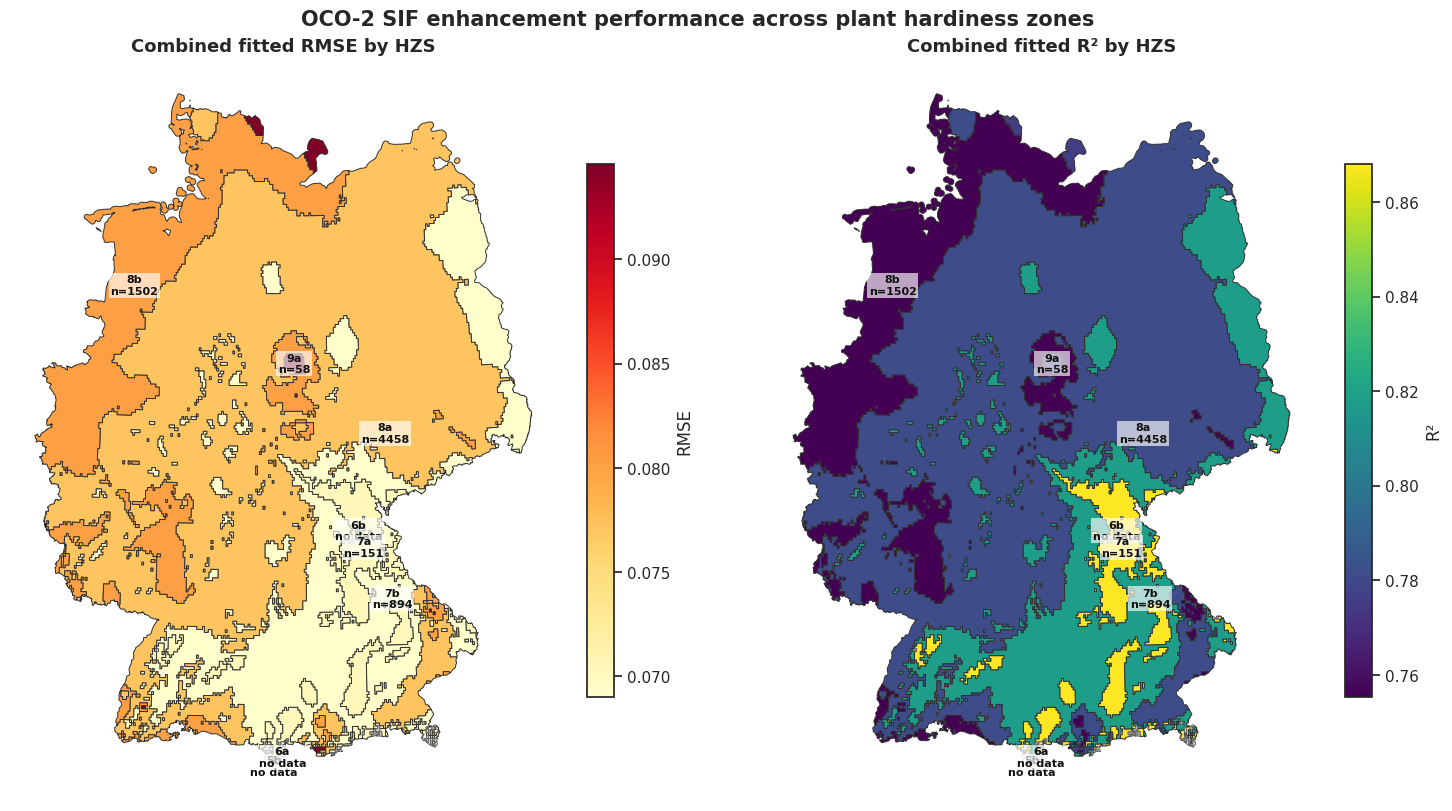

Saved: /kaggle/working/rq4_outputs/hzs_performance_choropleth_rmse_r2.pdf


In [35]:
hzs_zones = gpd.read_file(HZS_GPKG_PATH)

required_zone_columns = {'hzs', 'geometry'}
missing_zone_columns = required_zone_columns - set(hzs_zones.columns)
if missing_zone_columns:
    raise ValueError(
        f'HZS GeoPackage is missing columns: {sorted(missing_zone_columns)}'
    )

hzs_zones = hzs_zones[['hzs', 'geometry']].copy()
hzs_zones['hzs'] = hzs_zones['hzs'].astype('string').str.strip()
hzs_zones = hzs_zones[
    hzs_zones['hzs'].isin(INDIVIDUAL_HZS_ORDER)
].copy()

zone_metrics_for_map = hzs_combined_metrics.copy()
zone_metrics_for_map['hzs'] = (
    zone_metrics_for_map['group_value']
    .astype('string')
    .str.strip()
)
zone_metrics_for_map = zone_metrics_for_map[
    zone_metrics_for_map['hzs'].isin(INDIVIDUAL_HZS_ORDER)
].copy()

if 'n_chips' not in zone_metrics_for_map.columns:
    zone_metrics_for_map['n_chips'] = zone_metrics_for_map['n']

metric_columns = [
    'hzs', 'calibrated_rmse', 'calibrated_r2', 'n_chips'
]
hzs_map = hzs_zones.merge(
    zone_metrics_for_map[metric_columns],
    on='hzs',
    how='left',
    validate='one_to_one',
)

# EPSG:3035 gives Germany a suitable equal-area map projection.
hzs_map = hzs_map.to_crs(3035)
label_points = hzs_map.geometry.representative_point()

sns.set_theme(style='white')
figure, axes = plt.subplots(
    1, 2, figsize=(15, 8), constrained_layout=True
)

map_specs = [
    ('calibrated_rmse', 'Combined fitted RMSE by HZS', 'YlOrRd', 'RMSE'),
    ('calibrated_r2', 'Combined fitted R² by HZS', 'viridis', 'R²'),
]

for axis, (metric, title, cmap, legend_label) in zip(axes, map_specs):
    hzs_map.plot(
        column=metric,
        ax=axis,
        cmap=cmap,
        edgecolor='#303030',
        linewidth=0.7,
        legend=True,
        legend_kwds={
            'label': legend_label,
            'shrink': 0.72,
        },
        missing_kwds={
            'color': '#d9d9d9',
            'edgecolor': '#666666',
            'hatch': '///',
            'label': 'No individual-zone samples',
        },
    )

    for position, (_, row) in enumerate(hzs_map.iterrows()):
        point = label_points.iloc[position]
        n_text = (
            f"n={int(row['n_chips'])}"
            if pd.notna(row['n_chips'])
            else 'no data'
        )
        axis.text(
            point.x,
            point.y,
            f"{row['hzs']}\n{n_text}",
            ha='center',
            va='center',
            fontsize=8,
            fontweight='bold',
            color='#111111',
            bbox={
                'facecolor': 'white',
                'alpha': 0.65,
                'edgecolor': 'none',
                'pad': 1.2,
            },
        )

    axis.set_title(title, fontsize=13, fontweight='bold')
    axis.set_axis_off()

figure.suptitle(
    'OCO-2 SIF enhancement performance across plant hardiness zones',
    fontsize=15,
    fontweight='bold',
)

choropleth_path = (
    RQ4_OUTPUT_DIR / 'hzs_performance_choropleth_rmse_r2.pdf'
)
figure.savefig(
    choropleth_path,
    format='pdf',
    bbox_inches='tight',
)
plt.show()
plt.close(figure)

print('Saved:', choropleth_path)

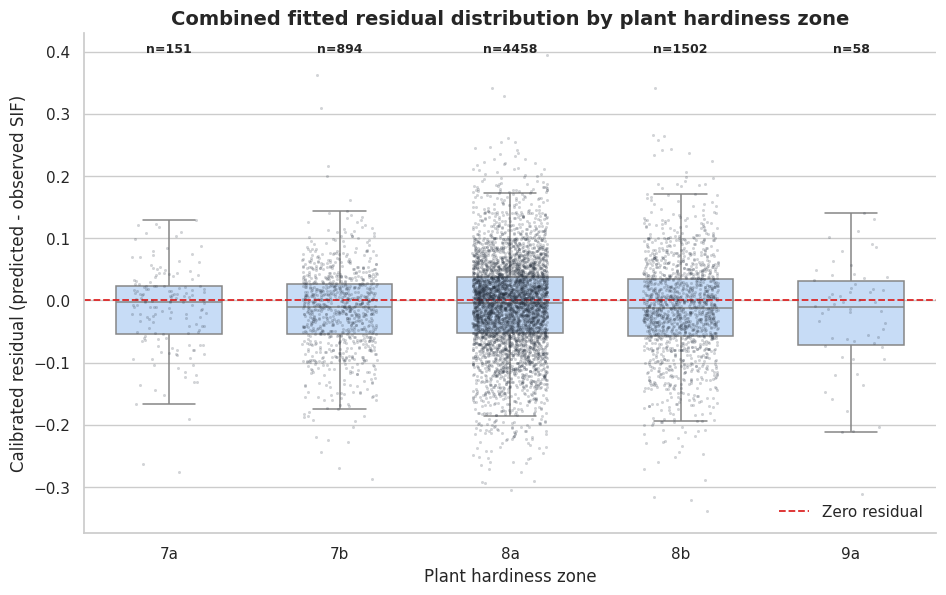

,hzs_values,n,residual_mean,residual_sd,residual_median,residual_q25,residual_q75
0,7a,151,-0.013982,0.069164,-0.002398,-0.053253,0.023737
1,7b,894,-0.015257,0.067325,-0.010281,-0.054376,0.026807
2,8a,4458,-0.008301,0.076722,-0.004484,-0.052461,0.037877
3,8b,1502,-0.013396,0.079194,-0.013007,-0.056515,0.035120
4,9a,58,-0.027228,0.091383,-0.011286,-0.071601,0.031590


Saved: /kaggle/working/rq4_outputs/residual_distribution_by_individual_hzs.pdf
Saved: /kaggle/working/rq4_outputs/residual_summary_by_individual_hzs.csv


In [36]:
zones_with_predictions = [
    zone for zone in INDIVIDUAL_HZS_ORDER
    if (rq4_predictions['hzs_values'] == zone).any()
]

zone_counts = (
    rq4_predictions.groupby('hzs_values', observed=False)
    .size()
    .reindex(zones_with_predictions)
)

residual_summary = (
    rq4_predictions.groupby('hzs_values', observed=False)
    .agg(
        n=('aggregation_id', 'size'),
        residual_mean=('residual_calibrated', 'mean'),
        residual_sd=('residual_calibrated', 'std'),
        residual_median=('residual_calibrated', 'median'),
        residual_q25=('residual_calibrated', lambda x: x.quantile(0.25)),
        residual_q75=('residual_calibrated', lambda x: x.quantile(0.75)),
    )
    .reindex(zones_with_predictions)
    .reset_index()
)

residual_summary_path = (
    RQ4_OUTPUT_DIR / 'residual_summary_by_individual_hzs.csv'
)
residual_summary.to_csv(residual_summary_path, index=False)

sns.set_theme(style='whitegrid')
figure, axis = plt.subplots(figsize=(11, 6.5))

sns.boxplot(
    data=rq4_predictions,
    x='hzs_values',
    y='residual_calibrated',
    order=zones_with_predictions,
    color='#bfdbfe',
    width=0.62,
    showfliers=False,
    linewidth=1.1,
    ax=axis,
)
sns.stripplot(
    data=rq4_predictions,
    x='hzs_values',
    y='residual_calibrated',
    order=zones_with_predictions,
    color='#1f2937',
    alpha=0.20,
    size=2.2,
    jitter=0.22,
    ax=axis,
)

axis.axhline(
    0,
    color='#dc2626',
    linestyle='--',
    linewidth=1.3,
    label='Zero residual',
)

for position, zone in enumerate(zones_with_predictions):
    axis.text(
        position,
        0.98,
        f'n={int(zone_counts.loc[zone])}',
        transform=axis.get_xaxis_transform(),
        ha='center',
        va='top',
        fontsize=9,
        fontweight='bold',
    )

axis.set_title(
    'Combined fitted residual distribution by plant hardiness zone',
    fontsize=14,
    fontweight='bold',
)
axis.set_xlabel('Plant hardiness zone')
axis.set_ylabel('Calibrated residual (predicted - observed SIF)')
axis.legend(frameon=False, loc='lower right')
sns.despine(ax=axis)

residual_plot_path = (
    RQ4_OUTPUT_DIR / 'residual_distribution_by_individual_hzs.pdf'
)
figure.savefig(
    residual_plot_path,
    format='pdf',
    bbox_inches='tight',
)
plt.show()
plt.close(figure)

display(residual_summary)
print('Saved:', residual_plot_path)
print('Saved:', residual_summary_path)

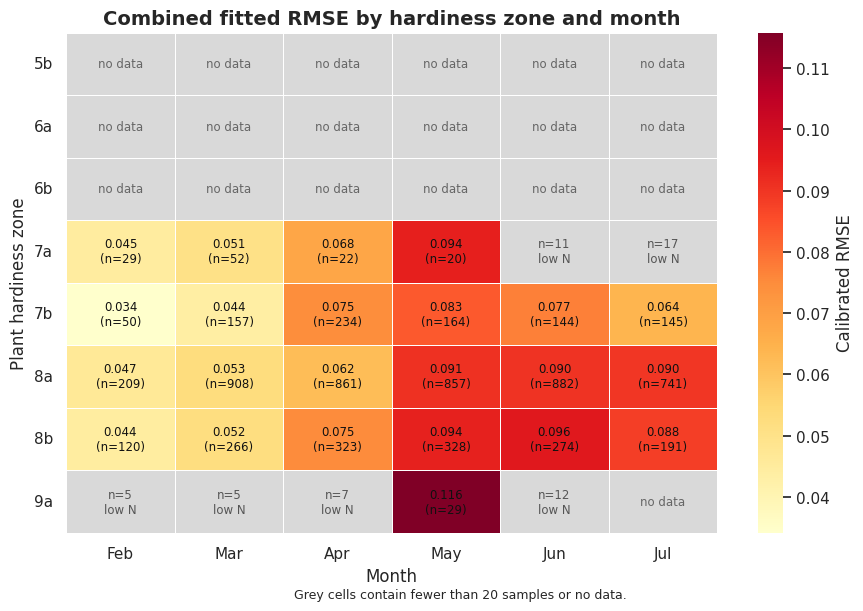

,hzs_values,month,n,rmse,mae,bias,r2,observed_mean,predicted_mean
0,7a,2,29.0,0.044730,0.032966,0.018730,-0.088471,0.050524,0.069254
1,7a,3,52.0,0.050525,0.038086,-0.018242,0.388323,0.126081,0.107839
2,7a,4,22.0,0.068072,0.053145,0.027661,0.040278,0.282941,0.310602
3,7a,5,20.0,0.094200,0.070720,-0.028595,0.216022,0.422448,0.393854
4,7a,6,11.0,0.120678,0.096486,-0.058208,-0.162834,0.574062,0.515854
5,7a,7,17.0,0.082849,0.072749,-0.064842,0.384311,0.493362,0.428520
6,7b,2,50.0,0.034114,0.029428,0.019055,-0.155561,0.057399,0.076455
7,7b,3,157.0,0.043732,0.033762,-0.009020,0.502766,0.113856,0.104836
8,7b,4,234.0,0.074750,0.056563,-0.028889,0.363577,0.295096,0.266207
9,7b,5,164.0,0.083356,0.064306,-0.028011,0.202030,0.437469,0.409458


Saved: /kaggle/working/rq4_outputs/hzs_month_rmse_heatmap.pdf
Saved: /kaggle/working/rq4_outputs/performance_by_individual_hzs_and_month.csv


In [37]:
def zone_month_performance(group: pd.DataFrame) -> pd.Series:
    observed = group['observed_sif'].to_numpy(dtype=np.float64)
    predicted = group['predicted_sif_calibrated'].to_numpy(dtype=np.float64)
    residual = predicted - observed
    n = len(group)

    if n >= 2 and np.var(observed) > 0:
        ss_residual = np.sum((observed - predicted) ** 2)
        ss_total = np.sum((observed - observed.mean()) ** 2)
        r2 = 1.0 - ss_residual / ss_total
    else:
        r2 = np.nan

    return pd.Series({
        'n': n,
        'rmse': float(np.sqrt(np.mean(residual ** 2))),
        'mae': float(np.mean(np.abs(residual))),
        'bias': float(np.mean(residual)),
        'r2': float(r2),
        'observed_mean': float(np.mean(observed)),
        'predicted_mean': float(np.mean(predicted)),
    })


zone_month_metrics = (
    rq4_predictions[
        rq4_predictions['month'].isin(MONTH_ORDER)
    ]
    .groupby(['hzs_values', 'month'], observed=False)
    .apply(zone_month_performance, include_groups=False)
    .reset_index()
)

zone_month_metrics_path = (
    RQ4_OUTPUT_DIR / 'performance_by_individual_hzs_and_month.csv'
)
zone_month_metrics.to_csv(zone_month_metrics_path, index=False)

rmse_matrix = (
    zone_month_metrics.pivot(
        index='hzs_values', columns='month', values='rmse'
    )
    .reindex(index=INDIVIDUAL_HZS_ORDER, columns=MONTH_ORDER)
)
n_matrix = (
    zone_month_metrics.pivot(
        index='hzs_values', columns='month', values='n'
    )
    .reindex(index=INDIVIDUAL_HZS_ORDER, columns=MONTH_ORDER)
)

valid_matrix = n_matrix >= MIN_ZONE_MONTH_N
rmse_display = rmse_matrix.where(valid_matrix)

if not valid_matrix.any().any():
    raise ValueError(
        f'No zone-month combination has at least {MIN_ZONE_MONTH_N} samples.'
    )

sns.set_theme(style='white')
figure, axis = plt.subplots(figsize=(10.5, 6.5))
axis.set_facecolor('#d9d9d9')

sns.heatmap(
    rmse_display,
    mask=~valid_matrix,
    cmap='YlOrRd',
    linewidths=0.7,
    linecolor='white',
    cbar_kws={'label': 'Calibrated RMSE'},
    annot=False,
    ax=axis,
)

for row_index, zone in enumerate(INDIVIDUAL_HZS_ORDER):
    for column_index, month in enumerate(MONTH_ORDER):
        n_value = n_matrix.loc[zone, month]
        rmse_value = rmse_matrix.loc[zone, month]

        if pd.isna(n_value) or int(n_value) == 0:
            label = 'no data'
            color = '#666666'
        elif int(n_value) < MIN_ZONE_MONTH_N:
            label = f'n={int(n_value)}\nlow N'
            color = '#555555'
        else:
            label = f'{rmse_value:.3f}\n(n={int(n_value)})'
            color = '#111111'

        axis.text(
            column_index + 0.5,
            row_index + 0.5,
            label,
            ha='center',
            va='center',
            fontsize=8.5,
            color=color,
        )

axis.set_xticklabels(
    [MONTH_LABELS[month] for month in MONTH_ORDER],
    rotation=0,
)
axis.set_yticklabels(INDIVIDUAL_HZS_ORDER, rotation=0)
axis.set_xlabel('Month')
axis.set_ylabel('Plant hardiness zone')
axis.set_title(
    'Combined fitted RMSE by hardiness zone and month',
    fontsize=14,
    fontweight='bold',
)

figure.text(
    0.5,
    0.01,
    f'Grey cells contain fewer than {MIN_ZONE_MONTH_N} samples or no data.',
    ha='center',
    fontsize=9,
)

heatmap_path = (
    RQ4_OUTPUT_DIR / 'hzs_month_rmse_heatmap.pdf'
)
figure.savefig(
    heatmap_path,
    format='pdf',
    bbox_inches='tight',
)
plt.show()
plt.close(figure)

display(zone_month_metrics)
print('Saved:', heatmap_path)
print('Saved:', zone_month_metrics_path)

In [38]:
# ---------------------------------------------------------------------------
# Combined train + validation + test metrics by observed SIF bin
# Descriptive fitted performance, not independent test performance
# ---------------------------------------------------------------------------

SIF_BIN_OUTPUT_DIR = Path('/kaggle/working/sif_bin_metrics')
SIF_BIN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

combined_bin_predictions = all_predictions.copy()

combined_bin_predictions['sif_bin'] = pd.cut(
    combined_bin_predictions['observed_sif'],
    bins=SIF_BIN_EDGES,
    labels=SIF_BIN_LABELS,
    right=False,
    include_lowest=True,
)

# Calculate raw and calibrated performance using the existing helper.
combined_sif_bin_metrics = metrics_by_group(
    combined_bin_predictions,
    'sif_bin',
)

# Add sample support information for each bin.
sif_bin_support = (
    combined_bin_predictions
    .groupby('sif_bin', observed=False)
    .agg(
        n_dates=('Delta_Date', 'nunique'),
        n_train=(
            'dataset_split',
            lambda x: int((x == 'train').sum()),
        ),
        n_validation=(
            'dataset_split',
            lambda x: int((x == 'validation').sum()),
        ),
        n_test=(
            'dataset_split',
            lambda x: int((x == 'test').sum()),
        ),
    )
    .reset_index()
)

sif_bin_support['group_value'] = (
    sif_bin_support['sif_bin'].astype('string')
)

sif_bin_support = sif_bin_support.drop(columns='sif_bin')

combined_sif_bin_metrics = combined_sif_bin_metrics.merge(
    sif_bin_support,
    on='group_value',
    how='left',
)

combined_sif_bin_metrics.insert(
    0,
    'evaluation_scope',
    'combined_train_validation_test_fitted_performance',
)

# Preserve the intended numerical bin order.
combined_sif_bin_metrics['group_value'] = pd.Categorical(
    combined_sif_bin_metrics['group_value'],
    categories=list(SIF_BIN_LABELS),
    ordered=True,
)

combined_sif_bin_metrics = (
    combined_sif_bin_metrics
    .sort_values('group_value')
    .reset_index(drop=True)
)

sif_bin_metrics_path = (
    SIF_BIN_OUTPUT_DIR
    / 'combined_fitted_performance_by_sif_bin.csv'
)

combined_sif_bin_metrics.to_csv(
    sif_bin_metrics_path,
    index=False,
)

display(combined_sif_bin_metrics)

print('Combined prediction rows:', f'{len(combined_bin_predictions):,}')
print('Saved:', sif_bin_metrics_path)

,evaluation_scope,group_variable,group_value,n,observed_min,observed_max,observed_mean,raw_predicted_mean,raw_rmse,raw_mae,raw_bias,raw_r2,calibrated_predicted_mean,calibrated_rmse,calibrated_mae,calibrated_bias,calibrated_r2,n_dates,n_train,n_validation,n_test
0,combined_train_validation_test_fitted_performance,sif_bin,"[-0.5,-0.25)",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
1,combined_train_validation_test_fitted_performance,sif_bin,"[-0.25,0)",66,-0.093745,-0.000051,-0.024619,0.082649,0.124847,0.107268,0.107268,-31.791526,0.085103,0.126407,0.109721,0.109721,-32.616038,20,64,2,0
2,combined_train_validation_test_fitted_performance,sif_bin,"[0,0.25)",2920,0.000174,0.249938,0.137274,0.154995,0.065429,0.047125,0.017722,-0.056786,0.155952,0.064527,0.046624,0.018678,-0.027849,174,2269,377,274
3,combined_train_validation_test_fitted_performance,sif_bin,"[0.25,0.5)",3846,0.250051,0.499936,0.372087,0.366539,0.066651,0.052483,-0.005548,0.077841,0.363119,0.066160,0.052040,-0.008968,0.091365,169,2860,441,545
4,combined_train_validation_test_fitted_performance,sif_bin,"[0.5,0.75)",1076,0.500075,0.749457,0.571241,0.477485,0.114383,0.095890,-0.093756,-3.064239,0.471769,0.118745,0.100817,-0.099472,-3.380122,99,856,108,112
5,combined_train_validation_test_fitted_performance,sif_bin,"[0.75,1)",12,0.751713,0.878349,0.787345,0.521527,0.269096,0.265818,-0.265818,-53.434648,0.514900,0.275592,0.272445,-0.272445,-56.094427,8,11,1,0
6,combined_train_validation_test_fitted_performance,sif_bin,"[1,1.25]",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0


Combined prediction rows: 7,920
Saved: /kaggle/working/sif_bin_metrics/combined_fitted_performance_by_sif_bin.csv


## 15. Training and Prediction Diagnostics

alt.Chart(...)

alt.LayerChart(...)

alt.Chart(...)

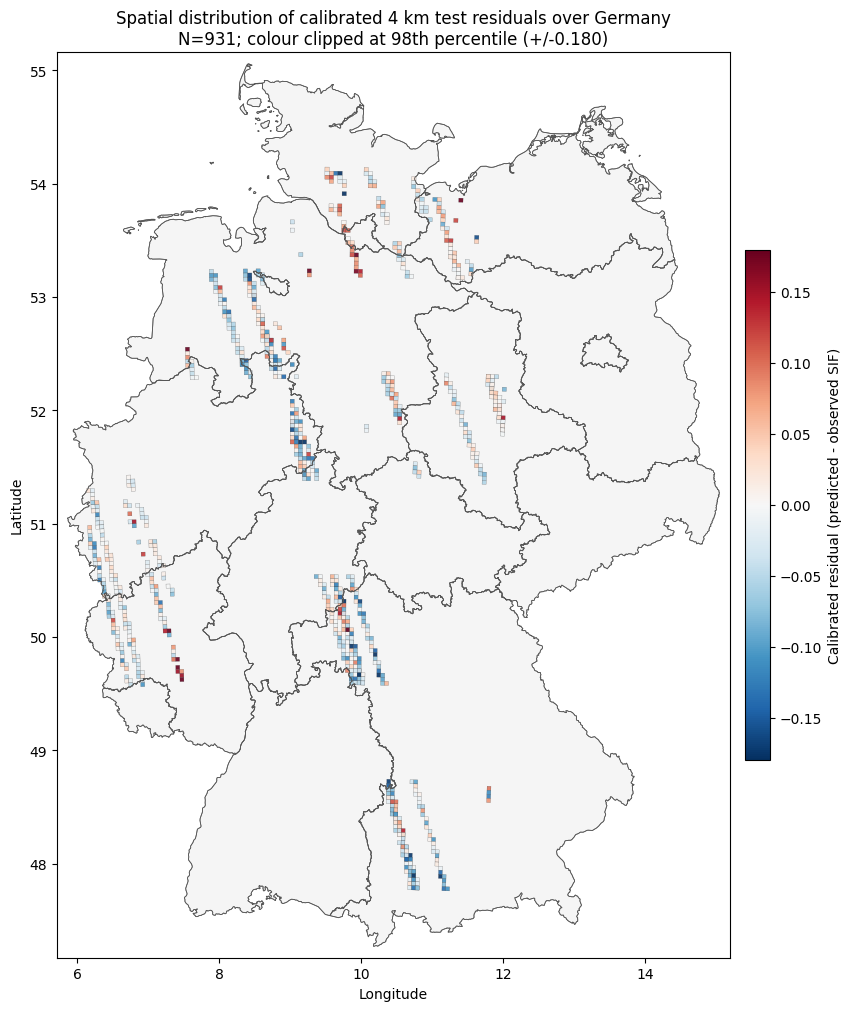

Saved spatial residual map: /kaggle/working/sentinel2_spatial_aggregate_4km_model/test_spatial_residual_map_germany.pdf


In [25]:
history_long = history_df.melt(
    id_vars=['epoch'],
    value_vars=['train_loss', 'val_rmse'],
    var_name='metric',
    value_name='value',
)
history_chart = (
    alt.Chart(history_long)
    .mark_line(point=True)
    .encode(
        x=alt.X('epoch:Q', title='Epoch'),
        y=alt.Y('value:Q', title='Metric value'),
        color=alt.Color('metric:N', title=None),
    )
    .properties(width=700, height=330, title='Training history')
)
display(history_chart)
#history_chart.save(str(OUTPUT_DIR / 'training_history.pdf'))

observed = test_predictions['observed_sif'].to_numpy(dtype=np.float64)
predicted = test_predictions[
    'predicted_sif_calibrated'
].to_numpy(dtype=np.float64)
plot_valid = np.isfinite(observed) & np.isfinite(predicted)
observed_plot = observed[plot_valid]
predicted_plot = predicted[plot_valid]

axis_min = math.floor(
    min(np.min(observed_plot), np.min(predicted_plot)) * 4
) / 4
axis_max = math.ceil(
    max(np.max(observed_plot), np.max(predicted_plot)) * 4
) / 4
if axis_max <= axis_min:
    axis_max = axis_min + 0.25

TICK_STEP = 0.25
axis_ticks = np.arange(
    axis_min,
    axis_max + TICK_STEP * 0.5,
    TICK_STEP,
).round(10).tolist()
shared_scale = alt.Scale(domain=[axis_min, axis_max], nice=False)
shared_axis = alt.Axis(values=axis_ticks, format='.2f')

# Assign every observation the count of its local 2D histogram bin.
DENSITY_BINS = 60
density_grid, observed_edges, predicted_edges = np.histogram2d(
    observed_plot,
    predicted_plot,
    bins=DENSITY_BINS,
    range=[[axis_min, axis_max], [axis_min, axis_max]],
)
observed_bin = np.clip(
    np.searchsorted(observed_edges, observed_plot, side='right') - 1,
    0,
    DENSITY_BINS - 1,
)
predicted_bin = np.clip(
    np.searchsorted(predicted_edges, predicted_plot, side='right') - 1,
    0,
    DENSITY_BINS - 1,
)
point_density = density_grid[observed_bin, predicted_bin]

density_points = pd.DataFrame({
    'observed_sif': observed_plot,
    'predicted_sif': predicted_plot,
    'density': point_density,
}).sort_values('density', ascending=True)

slope, intercept = np.polyfit(observed_plot, predicted_plot, deg=1)
line_x = np.asarray([axis_min, axis_max], dtype=np.float64)
regression_data = pd.DataFrame({
    'x': line_x,
    'y': intercept + slope * line_x,
})
diagonal_data = pd.DataFrame({
    'x': [axis_min, axis_max],
    'y': [axis_min, axis_max],
})

point_layer = (
    alt.Chart(density_points)
    .mark_circle(size=28, opacity=0.78, clip=True)
    .encode(
        x=alt.X(
            'observed_sif:Q',
            scale=shared_scale,
            axis=shared_axis,
            title='Observed 4 km aggregate SIF',
        ),
        y=alt.Y(
            'predicted_sif:Q',
            scale=shared_scale,
            axis=shared_axis,
            title='Calibrated predicted 4 km aggregate SIF',
        ),
        color=alt.Color(
            'density:Q',
            scale=alt.Scale(type='log', scheme='turbo', domainMin=1),
            title='Local density',
        ),
        tooltip=[
            alt.Tooltip('observed_sif:Q', format='.4f'),
            alt.Tooltip('predicted_sif:Q', format='.4f'),
            alt.Tooltip('density:Q', format='.0f'),
        ],
    )
)

diagonal = (
    alt.Chart(diagonal_data)
    .mark_line(color='black', strokeWidth=1.5, strokeDash=[6, 4])
    .encode(
        x=alt.X('x:Q', scale=shared_scale),
        y=alt.Y('y:Q', scale=shared_scale),
    )
)
regression_line = (
    alt.Chart(regression_data)
    .mark_line(color='#e31a1c', strokeWidth=2.0)
    .encode(
        x=alt.X('x:Q', scale=shared_scale),
        y=alt.Y('y:Q', scale=shared_scale),
    )
)

axis_span = axis_max - axis_min
annotation_data = pd.DataFrame({
    'x': [
        axis_min + 0.04 * axis_span,
        axis_min + 0.04 * axis_span,
    ],
    'y': [
        axis_max - 0.04 * axis_span,
        axis_max - 0.09 * axis_span,
    ],
    'label': [
        f'regression: y={slope:.3f}x{intercept:+.3f}',
        (
            f"RMSE={test_metrics_calibrated['rmse']:.4f}, "
            f"R2={test_metrics_calibrated['r2']:.3f}, "
            f"N={len(density_points):,}"
        ),
    ],
})
annotation = (
    alt.Chart(annotation_data)
    .mark_text(
        align='left',
        baseline='top',
        color='black',
        fontSize=13,
    )
    .encode(
        x=alt.X('x:Q', scale=shared_scale),
        y=alt.Y('y:Q', scale=shared_scale),
        text='label:N',
    )
)

density_title = (
    f"Test RMSE={test_metrics_calibrated['rmse']:.4f}, "
    f"R2={test_metrics_calibrated['r2']:.3f}"
)
density_chart = (
    (point_layer + diagonal + regression_line + annotation)
    .properties(width=620, height=620, title=density_title)
    .configure_view(strokeWidth=1)
)
display(density_chart)
#density_chart.save(
#    str(OUTPUT_DIR / 'test_observed_vs_predicted_density.pdf')
#)

residual_chart = (
    alt.Chart(test_predictions)
    .mark_bar()
    .encode(
        x=alt.X(
            'residual_calibrated:Q',
            bin=alt.Bin(maxbins=80),
            title='Calibrated predicted - observed SIF',
        ),
        y=alt.Y('count():Q', title='Count'),
    )
    .properties(width=700, height=320, title='Test residual distribution')
)
display(residual_chart)
#residual_chart.save(
#    str(OUTPUT_DIR / 'test_residual_distribution.pdf')
#)

# Join calibrated test residuals to the fixed-grid cell bounds.
spatial_columns = [
    'aggregation_id', 'cell_xmin', 'cell_ymin',
    'cell_xmax', 'cell_ymax',
]
missing_spatial_columns = [
    column for column in spatial_columns if column not in metadata.columns
]
if missing_spatial_columns:
    raise ValueError(
        f'Missing chip spatial columns: {missing_spatial_columns}'
    )
if not GERMANY_BOUNDARIES_PATH.exists():
    raise FileNotFoundError(
        f'{GERMANY_BOUNDARIES_PATH} not found. Update '
        'GERMANY_BOUNDARIES_PATH in the configuration cell.'
    )

test_spatial = test_predictions.merge(
    metadata[spatial_columns],
    on='aggregation_id',
    how='left',
    validate='one_to_one',
)
if test_spatial[spatial_columns[1:]].isna().any().any():
    raise ValueError('At least one test chip is missing its spatial bounds.')

test_residual_gdf = gpd.GeoDataFrame(
    test_spatial,
    geometry=[
        box(row.cell_xmin, row.cell_ymin, row.cell_xmax, row.cell_ymax)
        for row in test_spatial.itertuples(index=False)
    ],
    crs=CHIP_BOUNDS_CRS,
).to_crs(4326)
germany_states = gpd.read_file(GERMANY_BOUNDARIES_PATH).to_crs(4326)

# Saturate only the colour scale at the 98th percentile so isolated
# extreme residuals do not hide the spatial pattern of most cells.
absolute_residual = np.abs(
    test_residual_gdf['residual_calibrated'].to_numpy(dtype=np.float64)
)
color_limit = float(np.nanquantile(absolute_residual, 0.98))
if not np.isfinite(color_limit) or color_limit <= 0:
    color_limit = 1e-6
test_residual_gdf['residual_for_color'] = test_residual_gdf[
    'residual_calibrated'
].clip(-color_limit, color_limit)
residual_norm = TwoSlopeNorm(
    vmin=-color_limit,
    vcenter=0.0,
    vmax=color_limit,
)

residual_map_figure, residual_map_axis = plt.subplots(
    figsize=(8.5, 10), constrained_layout=True
)
germany_states.plot(
    ax=residual_map_axis,
    facecolor='#f5f5f5',
    edgecolor='#777777',
    linewidth=0.55,
)
test_residual_gdf.plot(
    ax=residual_map_axis,
    column='residual_for_color',
    cmap='RdBu_r',
    norm=residual_norm,
    edgecolor='#333333',
    linewidth=0.15,
    alpha=0.90,
)
# Draw state boundaries again so they remain visible above the cells.
germany_states.boundary.plot(
    ax=residual_map_axis,
    color='#555555',
    linewidth=0.60,
)

color_mappable = plt.cm.ScalarMappable(
    norm=residual_norm,
    cmap='RdBu_r',
)
color_mappable.set_array([])
residual_colorbar = residual_map_figure.colorbar(
    color_mappable,
    ax=residual_map_axis,
    fraction=0.035,
    pad=0.02,
)
residual_colorbar.set_label(
    'Calibrated residual (predicted - observed SIF)'
)

xmin, ymin, xmax, ymax = germany_states.total_bounds
residual_map_axis.set_xlim(xmin - 0.15, xmax + 0.15)
residual_map_axis.set_ylim(ymin - 0.10, ymax + 0.10)
residual_map_axis.set_xlabel('Longitude')
residual_map_axis.set_ylabel('Latitude')
residual_map_axis.set_title(
    'Spatial distribution of calibrated 4 km test residuals over Germany\n'
    f'N={len(test_residual_gdf):,}; colour clipped at '
    f'98th percentile (+/-{color_limit:.3f})'
)
residual_map_axis.grid(False)

RESIDUAL_MAP_PDF_PATH = OUTPUT_DIR / 'test_spatial_residual_map_germany.pdf'
residual_map_figure.savefig(
    RESIDUAL_MAP_PDF_PATH,
    format='pdf',
    bbox_inches='tight',
)
plt.show()
plt.close(residual_map_figure)
print('Saved spatial residual map:', RESIDUAL_MAP_PDF_PATH)

## 16. Example Predicted SIF Map and Aggregate Supervision

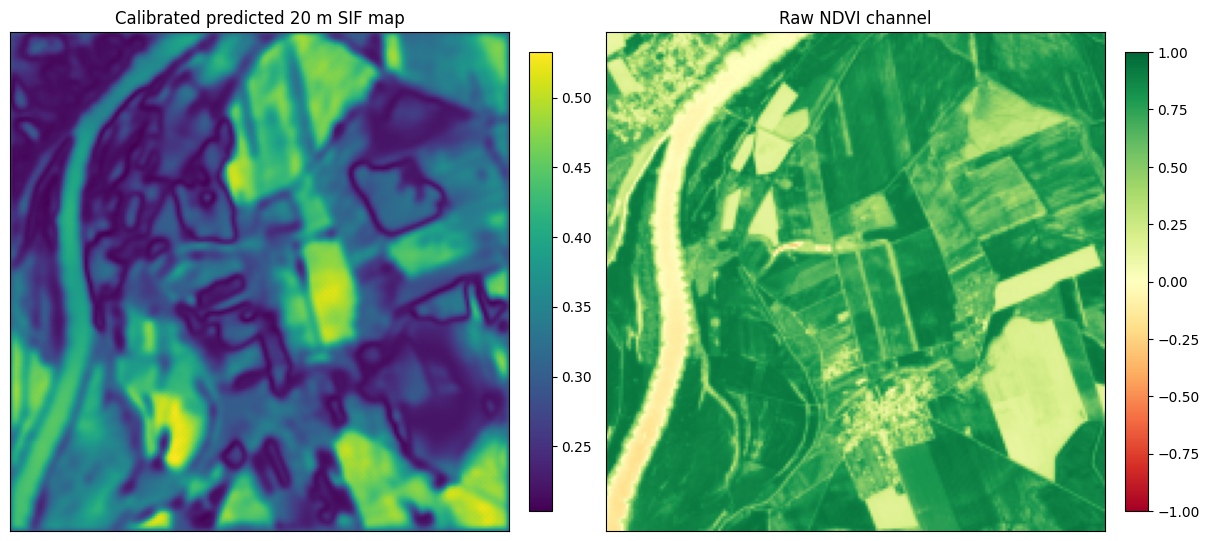

,aggregation_id,n_footprints,observed_aggregate_sif,predicted_aggregate_sif_calibrated,residual
0,s2_fixed_4000m_T32UPC_r00_c22_20190404_m0,12,0.270049,0.316436,0.046387


In [29]:
example_index = 0

raw_example_dataset = SentinelAggregateDataset(
    test_table.iloc[[example_index]].reset_index(drop=True),
    cache_size=1,
)

normalized_example_dataset = SentinelAggregateDataset(
    test_table.iloc[[example_index]].reset_index(drop=True),
    **dataset_kwargs,
)

raw_x, raw_weight, raw_y, raw_n, _ = raw_example_dataset[0]
norm_x, norm_weight, norm_y, norm_n, _ = normalized_example_dataset[0]

model.eval()

with torch.no_grad():
    with torch.autocast(
        device_type=DEVICE.type,
        dtype=torch.float16,
        enabled=AMP_ENABLED,
    ):
        example_pred_norm = model(
            norm_x[None].to(DEVICE)
        )[0, 0]

    example_pred_map_raw = denormalize_sif(
        example_pred_norm.float().cpu().numpy()
    )

    example_pred_map = apply_linear_calibration(
        example_pred_map_raw,
        calibration,
    )

ndvi_index = channel_names.index('ndvi')

figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5.5),
    constrained_layout=True,
)

image0 = axes[0].imshow(
    example_pred_map,
    cmap='viridis',
)
axes[0].set_title('Calibrated predicted 20 m SIF map')
figure.colorbar(
    image0,
    ax=axes[0],
    fraction=0.046,
    pad=0.04,
)

image1 = axes[1].imshow(
    raw_x[ndvi_index],
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
)
axes[1].set_title('Raw NDVI channel')
figure.colorbar(
    image1,
    ax=axes[1],
    fraction=0.046,
    pad=0.04,
)

for axis in axes:
    axis.set_xticks([])
    axis.set_yticks([])

figure.savefig(
    OUTPUT_DIR / 'example_predicted_sif_map_and_ndvi.pdf',
    format='pdf',
    bbox_inches='tight',
)

plt.show()
plt.close(figure)

# Aggregate the predicted map over the supervision footprint support.
example_predicted = float(
    (example_pred_map * raw_weight.numpy()).sum()
)
example_observed = float(raw_y)

display(pd.DataFrame([{
    'aggregation_id': test_table.iloc[example_index]['aggregation_id'],
    'n_footprints': int(raw_n),
    'observed_aggregate_sif': example_observed,
    'predicted_aggregate_sif_calibrated': example_predicted,
    'residual': example_predicted - example_observed,
}]))

In [39]:
# ---------------------------------------------------------------------------
# RQ3: 4 km spatial-aggregate performance summary
# ---------------------------------------------------------------------------

from pathlib import Path

RQ3_OUTPUT_DIR = Path('/kaggle/working/rq3_outputs')
RQ3_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

observed = test_predictions['observed_sif'].to_numpy(dtype=np.float64)
predicted = test_predictions[
    'predicted_sif_calibrated'
].to_numpy(dtype=np.float64)

finite = np.isfinite(observed) & np.isfinite(predicted)
observed = observed[finite]
predicted = predicted[finite]
residual = predicted - observed

test_metrics = regression_metrics(observed, predicted)

target_sd = float(np.std(observed, ddof=1))
target_iqr = float(
    np.quantile(observed, 0.75)
    - np.quantile(observed, 0.25)
)

if len(observed) >= 2 and np.var(observed) > 0:
    regression_slope, regression_intercept = np.polyfit(
        observed,
        predicted,
        1,
    )
else:
    regression_slope = np.nan
    regression_intercept = np.nan

normalized_rmse = (
    test_metrics['rmse'] / target_sd
    if target_sd > 0
    else np.nan
)

performance_row = pd.DataFrame([{
    'model': 'Sentinel-2 spatial U-Net',
    'supervision': 'spatially aggregated SIF',
    'target_support': '4 km fixed-grid cell',
    'minimum_footprints_per_target': 5,
    'predictor_resolution_m': 20,

    'n_train': len(train_table),
    'n_validation': len(val_table),
    'n_test': len(test_table),
    'n_test_dates': test_table['Delta_Date'].nunique(),

    'observed_mean': float(np.mean(observed)),
    'observed_sd': target_sd,
    'observed_iqr': target_iqr,
    'observed_min': float(np.min(observed)),
    'observed_max': float(np.max(observed)),
    'negative_target_fraction': float(np.mean(observed < 0)),

    'rmse': test_metrics['rmse'],
    'normalized_rmse': normalized_rmse,
    'mae': test_metrics['mae'],
    'bias': test_metrics['bias'],
    'r2': test_metrics['r2'],
    'regression_slope': float(regression_slope),
    'regression_intercept': float(regression_intercept),
    'residual_sd': float(np.std(residual, ddof=1)),
}])

performance_path = (
    RQ3_OUTPUT_DIR
    / 'spatial_aggregate_4km_performance_summary.csv'
)

performance_row.to_csv(performance_path, index=False)

display(performance_row)
print('Saved:', performance_path)

,model,supervision,target_support,minimum_footprints_per_target,predictor_resolution_m,n_train,n_validation,n_test,n_test_dates,observed_mean,observed_sd,observed_iqr,observed_min,observed_max,negative_target_fraction,rmse,normalized_rmse,mae,bias,r2,regression_slope,regression_intercept,residual_sd
0,Sentinel-2 spatial U-Net,spatially aggregated SIF,4 km fixed-grid cell,5,20,6060,929,931,21,0.325178,0.143664,0.203166,0.013132,0.72,0.0,0.070146,0.488263,0.052749,-0.014945,0.761343,0.725786,0.074223,0.068572


Saved: /kaggle/working/rq3_outputs/spatial_aggregate_4km_performance_summary.csv


In [40]:
rq3_spatial_test_values = test_predictions[
    [
        'aggregation_id',
        'Delta_Date',
        'measurement_mode',
        'mgrs_tile_t',
        'n_footprints',
        'observed_sif',
        'predicted_sif_calibrated',
        'residual_calibrated',
    ]
].copy()

rq3_spatial_test_values.insert(
    0,
    'model_label',
    '4 km spatial aggregate',
)

rq3_spatial_test_values.insert(
    1,
    'target_support',
    '4 km aggregate',
)

distribution_path = (
    RQ3_OUTPUT_DIR
    / 'spatial_aggregate_4km_test_targets_and_residuals.csv'
)

rq3_spatial_test_values.to_csv(
    distribution_path,
    index=False,
)

print('Saved:', distribution_path)

Saved: /kaggle/working/rq3_outputs/spatial_aggregate_4km_test_targets_and_residuals.csv


,footprint_bin,n_cells,n_dates,min_footprints,max_footprints,mean_footprints,mean_within_cell_target_sd,mean_target_standard_error,median_target_standard_error,observed_mean,observed_sd,rmse,normalized_rmse,mae,bias,r2,residual_sd
0,5-6,223.0,20.0,5.0,6.0,5.479821,0.140671,0.060328,0.052768,0.299433,0.143796,0.080385,0.559021,0.058452,-0.005581,0.686088,0.080371
1,7-8,216.0,20.0,7.0,8.0,7.500000,0.134809,0.049352,0.045447,0.316742,0.151198,0.070498,0.466259,0.052327,-0.014803,0.781591,0.069086
2,9-10,195.0,20.0,9.0,10.0,9.502564,0.126300,0.041002,0.037147,0.300510,0.153000,0.066880,0.437126,0.050140,-0.017282,0.807936,0.064775
3,11-12,157.0,17.0,11.0,12.0,11.503185,0.137217,0.040478,0.039046,0.344397,0.126906,0.061656,0.485843,0.048990,-0.019223,0.762443,0.058770
4,13+,140.0,14.0,13.0,18.0,13.621429,0.148240,0.040207,0.038358,0.392007,0.109623,0.065323,0.595892,0.052164,-0.022027,0.642358,0.061718


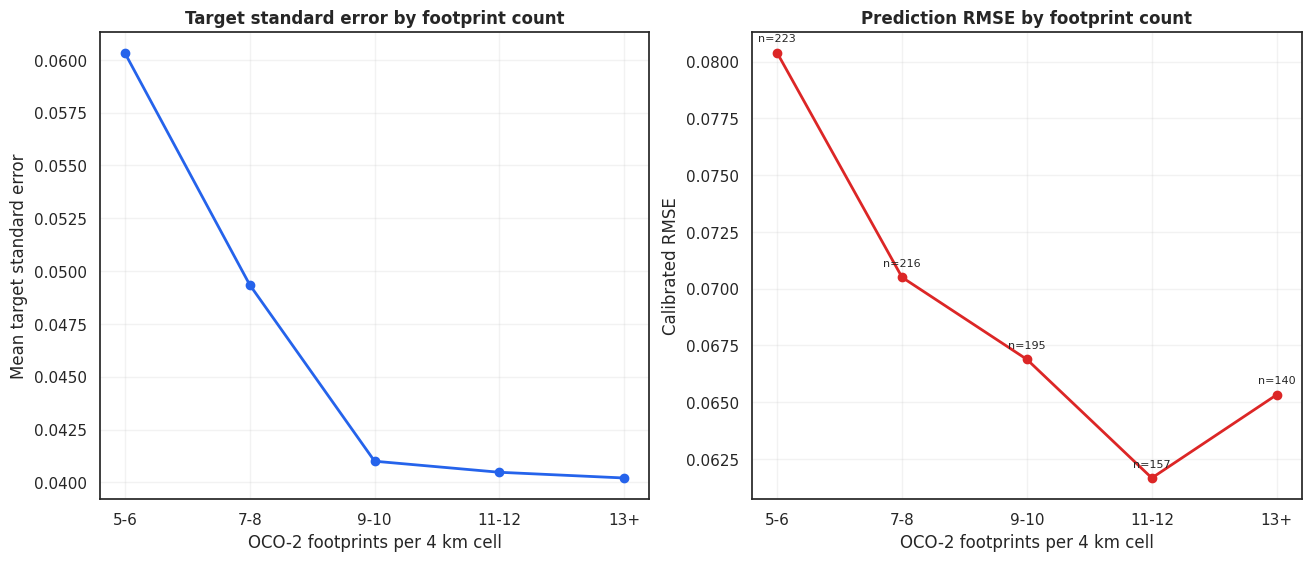

Saved: /kaggle/working/rq3_outputs/performance_by_4km_footprint_count.csv
Saved: /kaggle/working/rq3_outputs/effect_of_footprint_count_on_stability_and_rmse.pdf


In [41]:
# ---------------------------------------------------------------------------
# RQ3: Effect of footprint count within 4 km aggregate cells
# ---------------------------------------------------------------------------

support_metadata = (
    test_table[
        [
            'aggregation_id',
            'target_sd',
            'target_se',
        ]
    ]
    .drop_duplicates('aggregation_id')
)

footprint_analysis = (
    test_predictions
    .drop(
        columns=['target_sd', 'target_se'],
        errors='ignore',
    )
    .merge(
        support_metadata,
        on='aggregation_id',
        how='left',
        validate='one_to_one',
    )
)

footprint_analysis['footprint_bin'] = pd.cut(
    footprint_analysis['n_footprints'],
    bins=[4, 6, 8, 10, 12, np.inf],
    labels=['5-6', '7-8', '9-10', '11-12', '13+'],
    right=True,
)

footprint_analysis['calibrated_residual'] = (
    footprint_analysis['predicted_sif_calibrated']
    - footprint_analysis['observed_sif']
)


def summarize_footprint_bin(group):
    observed = group['observed_sif'].to_numpy(dtype=np.float64)
    predicted = group[
        'predicted_sif_calibrated'
    ].to_numpy(dtype=np.float64)

    metrics = regression_metrics(observed, predicted)
    residual = predicted - observed
    observed_sd = float(np.std(observed, ddof=1))

    return pd.Series({
        'n_cells': len(group),
        'n_dates': group['Delta_Date'].nunique(),

        'min_footprints': int(group['n_footprints'].min()),
        'max_footprints': int(group['n_footprints'].max()),
        'mean_footprints': float(group['n_footprints'].mean()),

        'mean_within_cell_target_sd': float(
            group['target_sd'].mean()
        ),
        'mean_target_standard_error': float(
            group['target_se'].mean()
        ),
        'median_target_standard_error': float(
            group['target_se'].median()
        ),

        'observed_mean': float(np.mean(observed)),
        'observed_sd': observed_sd,

        'rmse': metrics['rmse'],
        'normalized_rmse': (
            metrics['rmse'] / observed_sd
            if observed_sd > 0
            else np.nan
        ),
        'mae': metrics['mae'],
        'bias': metrics['bias'],
        'r2': metrics['r2'],
        'residual_sd': float(np.std(residual, ddof=1)),
    })


footprint_count_metrics = (
    footprint_analysis
    .groupby(
        'footprint_bin',
        observed=True,
    )
    .apply(
        summarize_footprint_bin,
        include_groups=False,
    )
    .reset_index()
)

footprint_count_path = (
    RQ3_OUTPUT_DIR
    / 'performance_by_4km_footprint_count.csv'
)

footprint_count_metrics.to_csv(
    footprint_count_path,
    index=False,
)

display(footprint_count_metrics)

# Plot target uncertainty and prediction error.
x_positions = np.arange(len(footprint_count_metrics))
x_labels = footprint_count_metrics[
    'footprint_bin'
].astype(str)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.5),
    constrained_layout=True,
)

axes[0].plot(
    x_positions,
    footprint_count_metrics[
        'mean_target_standard_error'
    ],
    marker='o',
    linewidth=2,
    color='#2563eb',
)

axes[0].set_title(
    'Target standard error by footprint count',
    fontweight='bold',
)
axes[0].set_xlabel('OCO-2 footprints per 4 km cell')
axes[0].set_ylabel('Mean target standard error')
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(x_labels)
axes[0].grid(alpha=0.25)

axes[1].plot(
    x_positions,
    footprint_count_metrics['rmse'],
    marker='o',
    linewidth=2,
    color='#dc2626',
)

axes[1].set_title(
    'Prediction RMSE by footprint count',
    fontweight='bold',
)
axes[1].set_xlabel('OCO-2 footprints per 4 km cell')
axes[1].set_ylabel('Calibrated RMSE')
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(x_labels)
axes[1].grid(alpha=0.25)

for position, row in footprint_count_metrics.iterrows():
    axes[1].annotate(
        f"n={int(row['n_cells'])}",
        (
            position,
            row['rmse'],
        ),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=8,
    )

footprint_effect_path = (
    RQ3_OUTPUT_DIR
    / 'effect_of_footprint_count_on_stability_and_rmse.pdf'
)

figure.savefig(
    footprint_effect_path,
    format='pdf',
    bbox_inches='tight',
)

plt.show()
plt.close(figure)

print('Saved:', footprint_count_path)
print('Saved:', footprint_effect_path)

## 17. Save Model, Predictions, Splits, and Metrics

In [28]:
history_path = OUTPUT_DIR / 'training_history.csv'
val_predictions_path = OUTPUT_DIR / 'validation_predictions.csv'
test_predictions_path = OUTPUT_DIR / 'test_predictions.csv'
group_metrics_path = OUTPUT_DIR / 'test_group_metrics.csv'
split_path = OUTPUT_DIR / 'aggregate_chip_splits.csv'
component_path = OUTPUT_DIR / 'split_components.csv'
checkpoint_path = OUTPUT_DIR / 'sentinel2_spatial_aggregate_4km_unet.pt'
metrics_path = OUTPUT_DIR / 'metrics.json'

history_df.to_csv(history_path, index=False)
val_predictions.to_csv(val_predictions_path, index=False)
test_predictions.to_csv(test_predictions_path, index=False)
group_metrics.to_csv(group_metrics_path, index=False)

chip_splits = pd.concat([
    train_table,
    val_table,
    test_table,
], ignore_index=True)[
    [
        'aggregation_id', 'Delta_Date', 'product_path', 'split_component',
        'split', 'mgrs_tile_t', 'measurement_mode', 'n_footprints'
    ]
]
chip_splits.to_csv(split_path, index=False)
split_components.to_csv(component_path, index=False)

checkpoint = {
    'model_state_dict': best_state,
    'model_class': 'ThreeLevelUNet',
    'channel_names': channel_names,
    'target_column': TARGET_COL,
    'base_channels': BASE_CHANNELS,
    'channel_mean': channel_mean,
    'channel_std': channel_std,
    'target_mean': target_mean,
    'target_std': target_std,
    'normalize_target': NORMALIZE_TARGET,
    'calibration': calibration,
    'best_epoch': best_epoch,
    'best_validation_rmse': best_val_rmse,
    'config': {
        'batch_size': BATCH_SIZE,
        'gradient_accumulation_steps': GRADIENT_ACCUMULATION_STEPS,
        'epochs': EPOCHS,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'huber_beta': HUBER_BETA,
        'seed': SEED,
        'split_grouping': ['Delta_Date', 'product_path'],
        'split_balance_marginals': [
            'month', 'measurement_mode', 'mgrs_tile_t'
        ],
        'split_allocation': 'chip_count_aware_component_search',
        'max_samples_for_stats': MAX_SAMPLES_FOR_STATS,
        'amp_enabled': AMP_ENABLED,
        'equal_cell_loss_weight': True,
    },
}
torch.save(checkpoint, checkpoint_path)

metrics_payload = {
    'best_epoch': best_epoch,
    'best_validation_rmse_during_training': best_val_rmse,
    'validation_raw': val_metrics_raw,
    'validation_calibrated': val_metrics_calibrated,
    'test_raw': test_metrics_raw,
    'test_calibrated': test_metrics_calibrated,
    'calibration': calibration,
    'n_train_chips': len(train_table),
    'n_validation_chips': len(val_table),
    'n_test_chips': len(test_table),
    'n_train_dates': int(train_table['Delta_Date'].nunique()),
    'n_validation_dates': int(val_table['Delta_Date'].nunique()),
    'n_test_dates': int(test_table['Delta_Date'].nunique()),
    'n_train_products': int(train_table['product_path'].nunique()),
    'n_validation_products': int(val_table['product_path'].nunique()),
    'n_test_products': int(test_table['product_path'].nunique()),
    'stats_cache_path': str(stats_cache_path),
}
with metrics_path.open('w', encoding='utf-8') as file:
    json.dump(metrics_payload, file, indent=2)

print('Saved:')
for path in [
    history_path, val_predictions_path, test_predictions_path,
    group_metrics_path, split_path, component_path,
    checkpoint_path, metrics_path,
]:
    print(' -', path)

Saved:
 - /kaggle/working/sentinel2_spatial_aggregate_4km_model/training_history.csv
 - /kaggle/working/sentinel2_spatial_aggregate_4km_model/validation_predictions.csv
 - /kaggle/working/sentinel2_spatial_aggregate_4km_model/test_predictions.csv
 - /kaggle/working/sentinel2_spatial_aggregate_4km_model/test_group_metrics.csv
 - /kaggle/working/sentinel2_spatial_aggregate_4km_model/aggregate_chip_splits.csv
 - /kaggle/working/sentinel2_spatial_aggregate_4km_model/split_components.csv
 - /kaggle/working/sentinel2_spatial_aggregate_4km_model/sentinel2_spatial_aggregate_4km_unet.pt
 - /kaggle/working/sentinel2_spatial_aggregate_4km_model/metrics.json
